<div style="background:linear-gradient(135deg,#0f0c29,#302b63,#24243e);padding:50px 40px;border-radius:20px;text-align:center;margin-bottom:30px;box-shadow:0 20px 60px rgba(0,0,0,0.5);">
  <h1 style="font-family:'Segoe UI',sans-serif;font-size:3em;font-weight:900;color:#fff;margin:0;letter-spacing:4px;text-shadow:0 0 30px rgba(120,80,255,0.8);">🌐 URBANSCOPE MAP</h1>
  <p style="font-family:'Segoe UI',sans-serif;font-size:1.3em;color:#a78bfa;margin:12px 0 0 0;letter-spacing:2px;font-weight:300;">MULTI-DOMAIN ANALYTICS PLATFORM</p>
  <div style="height:2px;background:linear-gradient(90deg,transparent,#7c3aed,#06b6d4,#7c3aed,transparent);margin:20px auto;width:60%;"></div>
  <p style="color:#94a3b8;font-size:1em;font-family:monospace;margin:0;">AI-Powered Digital Twin · Risk · Safety · Sustainability · India</p>
</div>

---
## 📦 Phase 1 · System Bootstrap — Imports & Configuration

In [25]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib, matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ── Global Palette ─────────────────────────────────────────────────────────
DARK_BG     = '#0d1117'
PANEL_BG    = '#161b22'
CARD_BG     = '#1c2333'
BORDER      = '#30363d'
TEXT_PRI    = '#e6edf3'
TEXT_SEC    = '#8b949e'
ACCENT_PUR  = '#7c3aed'
ACCENT_CYAN = '#06b6d4'
ACCENT_EMER = '#10b981'
ACCENT_ROSE = '#f43f5e'
ACCENT_AMB  = '#f59e0b'
ACCENT_BLUE = '#3b82f6'
PALETTE = [ACCENT_CYAN,ACCENT_PUR,ACCENT_EMER,ACCENT_ROSE,
           ACCENT_AMB,ACCENT_BLUE,'#a78bfa','#34d399','#fb923c','#e879f9']

plt.rcParams.update({
    'figure.facecolor': DARK_BG, 'axes.facecolor': PANEL_BG,
    'axes.edgecolor': BORDER, 'axes.labelcolor': TEXT_SEC,
    'axes.titlecolor': TEXT_PRI, 'axes.titlesize': 13,
    'axes.titleweight': 'bold', 'axes.labelsize': 10,
    'xtick.color': TEXT_SEC, 'ytick.color': TEXT_SEC,
    'xtick.labelsize': 8, 'ytick.labelsize': 8,
    'grid.color': BORDER, 'grid.linewidth': 0.5, 'grid.alpha': 0.5,
    'legend.facecolor': CARD_BG, 'legend.edgecolor': BORDER,
    'legend.labelcolor': TEXT_PRI, 'legend.fontsize': 8,
    'text.color': TEXT_PRI, 'font.family': 'monospace',
    'axes.spines.top': False, 'axes.spines.right': False,
})

def styled_title(ax, title, subtitle=None, accent=ACCENT_CYAN):
    ax.set_title(title, color=TEXT_PRI, fontsize=12, fontweight='bold',
                 pad=12, fontfamily='monospace')
    if subtitle:
        ax.text(0.5, 1.02, subtitle, transform=ax.transAxes,
                ha='center', fontsize=7.5, color=TEXT_SEC, style='italic')

def section_header(title, emoji=''):
    w = 72
    print(f'\n{"─"*w}\n  {emoji}  {title}\n{"─"*w}\n')

section_header('UrbanScope MAP — Environment Ready', '✅')
import sklearn
print(f'  NumPy {np.__version__} | Pandas {pd.__version__} | '
      f'Matplotlib {matplotlib.__version__}')
print(f'  Seaborn {sns.__version__} | Scikit-learn {sklearn.__version__}')


────────────────────────────────────────────────────────────────────────
  ✅  UrbanScope MAP — Environment Ready
────────────────────────────────────────────────────────────────────────

  NumPy 2.1.3 | Pandas 2.2.3 | Matplotlib 3.10.0
  Seaborn 0.13.2 | Scikit-learn 1.6.1


---
## 📂 Phase 2 · Data Ingestion — Loading All Six Datasets

In [3]:
# ── Place all CSV files in the same folder as this notebook (or adjust DATA_DIR) ──
DATA_DIR = Path('.')

def load_csv(name, **kwargs):
    for candidate in [DATA_DIR / name,
                      DATA_DIR / 'datasets' / name,
                      Path('/mnt/data') / name]:
        if candidate.exists():
            df = pd.read_csv(candidate, na_values=['NA','N/A','null','NULL',''],
                             keep_default_na=True, **kwargs)
            # strip trailing carriage returns from all string columns
            df = df.apply(lambda c: c.str.strip().str.rstrip('\r')
                          if c.dtype == object else c)
            section_header(f'Loaded: {name}  →  {df.shape[0]:,} rows × {df.shape[1]} cols', '📄')
            print(df.dtypes.to_string())
            miss = df.isnull().sum()
            miss = miss[miss > 0]
            print('\n  Null counts:')
            print('  None detected ✓' if miss.empty else miss.to_string())
            return df
    raise FileNotFoundError(f'{name} not found. Place it next to the notebook.')

df_aqi       = load_csv('aqi.csv')
df_crime     = load_csv('crime.csv')
df_accidents = load_csv('road_accidents.csv')
df_gdp       = load_csv('gdp.csv')
df_pop       = load_csv('population.csv')
df_rain      = load_csv('rainfall.csv')


────────────────────────────────────────────────────────────────────────
  📄  Loaded: aqi.csv  →  3,456 rows × 11 cols
────────────────────────────────────────────────────────────────────────

country           object
state             object
city              object
station           object
last_update       object
latitude         float64
longitude        float64
pollutant_id      object
pollutant_min    float64
pollutant_max    float64
pollutant_avg    float64

  Null counts:
pollutant_min    241
pollutant_max    241
pollutant_avg    241

────────────────────────────────────────────────────────────────────────
  📄  Loaded: crime.csv  →  39 rows × 8 cols
────────────────────────────────────────────────────────────────────────

Sl. No.                                             object
State/UT                                            object
2020                                                 int64
2021                                                 int64
2022                    

---
## 🧹 Phase 3 · Data Cleaning — Six Datasets

In [26]:
# ── AQI CLEANING ──────────────────────────────────────────────────────────────
aqi = df_aqi.copy()
aqi['state'] = (aqi['state'].str.strip()
                             .str.replace('_',' ')
                             .str.title())
aqi['pollutant_avg'] = pd.to_numeric(aqi['pollutant_avg'], errors='coerce')
aqi = aqi.dropna(subset=['pollutant_avg'])

# Pollutants we care about
KEEP_POLLUTANTS = ['PM2.5','PM10','NO2','NH3','SO2','CO','OZONE']

aqi_wide = aqi.pivot_table(
    index='state', columns='pollutant_id',
    values='pollutant_avg', aggfunc='mean'
).reset_index()
aqi_wide.columns.name = None

# Keep only recognised pollutant columns
poll_present = [p for p in KEEP_POLLUTANTS if p in aqi_wide.columns]
aqi_wide = aqi_wide[['state'] + poll_present]

# Weighted composite AQI (IS-based severity weights)
WEIGHTS = {'PM2.5':0.30,'PM10':0.25,'NO2':0.15,'SO2':0.10,
           'CO':0.10,'NH3':0.05,'OZONE':0.05}
w_total = sum(WEIGHTS.get(p,0) for p in poll_present)
aqi_wide['AQI_Composite'] = sum(
    aqi_wide[p].fillna(aqi_wide[p].median()) * WEIGHTS.get(p,0)
    for p in poll_present
) / max(w_total, 1e-9)
aqi_wide['AQI_Composite'] = aqi_wide['AQI_Composite'].round(2)

aqi_pivot = aqi_wide.copy()

section_header('AQI — Cleaned', '✅')
print(f'  States: {aqi_pivot.shape[0]}')
print(aqi_pivot[['state','AQI_Composite']].head(6).to_string(index=False))


────────────────────────────────────────────────────────────────────────
  ✅  AQI — Cleaned
────────────────────────────────────────────────────────────────────────

  States: 29
         state  AQI_Composite
Andhra Pradesh          45.47
         Assam          25.92
         Bihar          46.49
    Chandigarh          22.97
  Chhattisgarh          34.12
         Delhi          57.65


In [27]:
# ── CRIME CLEANING ────────────────────────────────────────────────────────────
crime = df_crime.copy()
crime.rename(columns={
    'State/UT':'state', '2020':'crime_2020', '2021':'crime_2021', '2022':'crime_2022',
    'Mid-Year Projected Population (in Lakhs) (2022)':'pop_lakhs',
    'Rate of Cognizable Crimes (IPC) (2022)':'crime_rate_2022',
    'Chargesheeting Rate (2022)':'chargesheeting_rate'
}, inplace=True)
crime.drop(columns=[c for c in ['Sl. No.'] if c in crime.columns], inplace=True)
crime['state'] = crime['state'].str.strip().str.title()
crime = crime[~crime['state'].str.contains(
    r'total|union territory|^states$|grand', case=False, na=False, regex=True)]

for col in ['crime_2020','crime_2021','crime_2022','pop_lakhs',
            'crime_rate_2022','chargesheeting_rate']:
    crime[col] = pd.to_numeric(
        crime[col].astype(str).str.replace(',',''), errors='coerce')

crime['crime_yoy_pct'] = (
    (crime['crime_2022'] - crime['crime_2021']) /
    crime['crime_2021'].replace(0, np.nan) * 100).round(2)

for col in crime.select_dtypes(include=np.number).columns:
    crime[col] = crime[col].fillna(crime[col].median())

section_header('Crime — Cleaned', '✅')
print(f'  States: {crime.shape[0]}')
print(crime[['state','crime_2022','crime_rate_2022','crime_yoy_pct']].head(6).to_string(index=False))


────────────────────────────────────────────────────────────────────────
  ✅  Crime — Cleaned
────────────────────────────────────────────────────────────────────────

  States: 36
            state  crime_2022  crime_rate_2022  crime_yoy_pct
   Andhra Pradesh      158547            299.0         -11.73
Arunachal Pradesh        2308            148.8         -12.11
            Assam       59315            167.1         -50.52
            Bihar      211079            168.1          13.48
     Chhattisgarh       73822            246.5           4.68
              Goa        2711            172.8          29.16


In [28]:
# ── ROAD ACCIDENTS CLEANING ───────────────────────────────────────────────────
acc = df_accidents.copy()
acc.rename(columns={
    'State/UT/City':'state',
    'Road Accidents - Cases':'road_cases',
    'Road Accidents - Injured':'road_injured',
    'Road Accidents - Died':'road_deaths',
    'Total Traffic Accidents - Cases':'total_acc_cases',
    'Total Traffic Accidents - Injured':'total_acc_injured',
    'Total Traffic Accidents - Died':'total_acc_deaths',
}, inplace=True)
acc.drop(columns=[c for c in ['Sl. No.'] if c in acc.columns], inplace=True)
acc['state'] = acc['state'].str.strip().str.title()

# Canonical state list — includes common typo variants
INDIAN_STATES = {
    'Andhra Pradesh','Arunachal Pradesh','Assam','Bihar','Chhattisgarh','Goa',
    'Gujarat','Haryana','Himachal Pradesh','Jharkhand','Karnataka','Kerala',
    'Madhya Pradesh','Maharashtra','Manipur','Meghalaya','Mizoram','Nagaland',
    'Odisha','Punjab','Rajasthan','Sikkim','Tamil Nadu','Telangana','Tripura',
    'Uttar Pradesh','Uttarakhand','West Bengal','Delhi','Jammu & Kashmir',
    'Ladakh','Puducherry','Chandigarh','Andaman & Nicobar Islands',
    'Dadra And Nagar Haveli And Daman And Diu','Lakshadweep',
    # typo variants present in this CSV
    'Dadra And Nicoabr Haveli And Daman And Diu',
}
# Repair known typo
acc['state'] = acc['state'].str.replace(
    r'Nicoabr', 'Nagar', regex=True)
acc = acc[acc['state'].isin(INDIAN_STATES)].reset_index(drop=True)

for col in ['road_cases','road_injured','road_deaths',
            'total_acc_cases','total_acc_injured','total_acc_deaths']:
    acc[col] = pd.to_numeric(acc[col], errors='coerce')

acc['road_fatality_rate'] = (
    acc['road_deaths'] / acc['road_cases'].replace(0, np.nan) * 100).round(2)

for col in acc.select_dtypes(include=np.number).columns:
    acc[col] = acc[col].fillna(acc[col].median())

section_header('Road Accidents — Cleaned', '✅')
print(f'  States: {acc.shape[0]}')
print(acc[['state','road_cases','road_deaths','road_fatality_rate']].head(6).to_string(index=False))


────────────────────────────────────────────────────────────────────────
  ✅  Road Accidents — Cleaned
────────────────────────────────────────────────────────────────────────

  States: 34
            state  road_cases  road_deaths  road_fatality_rate
   Andhra Pradesh       21070         8293               39.36
Arunachal Pradesh         215          152               70.70
            Assam        7028         3060               43.54
            Bihar       10801         8898               82.38
     Chhattisgarh       13091         5890               44.99
              Goa        3012          274                9.10


In [29]:
# ── GDP CLEANING ──────────────────────────────────────────────────────────────
# Schema: Item (sector row), quarterly Values and Growth Rates 2011-12 to 2022-23
gdp = df_gdp.copy()
gdp['Item'] = gdp['Item'].str.strip()

val_cols = [c for c in gdp.columns if 'Value (Rs. in crore)' in c]
gr_cols  = [c for c in gdp.columns if 'Growth Rate (%)' in c]

# Parse financial year from column names  e.g.  "Value ... - 2021-22 - Q1"
years = list(dict.fromkeys(c.split(' - ')[1] for c in val_cols))

annual_records = []
for yr in years:
    yr_val_cols = [c for c in val_cols if f' - {yr} - ' in c]
    yr_gr_cols  = [c for c in gr_cols  if f' - {yr} - ' in c]
    for _, row in gdp.iterrows():
        vals = pd.to_numeric(pd.Series([row[c] for c in yr_val_cols]), errors='coerce')
        grs  = pd.to_numeric(pd.Series([row[c] for c in yr_gr_cols]),  errors='coerce')
        annual_records.append({
            'sector':          row['Item'],
            'year':            yr,
            'gdp_value_cr':    vals.sum(skipna=True)  if vals.notna().any() else np.nan,
            'growth_rate_pct': grs.mean(skipna=True)  if grs.notna().any()  else np.nan,
        })

gdp_annual = pd.DataFrame(annual_records).dropna(subset=['gdp_value_cr'])

# ── FIX: robust GDP-total row filter ─────────────────────────────────────────
# Real item names are things like "10. GDP" or "19. GDP" (numbered rows)
# Use word-boundary match on GDP; exclude purely sector GVA lines
gdp_total = gdp_annual[
    gdp_annual['sector'].str.upper().str.contains(r'\bGDP\b', regex=True, na=False)
]
# If still empty fall back to any row containing 'gross domestic'
if gdp_total.empty:
    gdp_total = gdp_annual[
        gdp_annual['sector'].str.lower().str.contains('gross domestic', na=False)]

gdp_sector = gdp_annual[~gdp_annual['sector'].isin(gdp_total['sector'])]

section_header('GDP — Cleaned', '✅')
print(f'  Sectors: {gdp_sector["sector"].nunique()}  |  Years: {gdp_annual["year"].nunique()}')
print(f'  GDP total rows found: {len(gdp_total)}')
if not gdp_total.empty:
    print(gdp_total[['sector','year','gdp_value_cr','growth_rate_pct']].head(6).to_string(index=False))
else:
    print('  ⚠ No GDP-total rows matched — check Item column values in gdp.csv')


────────────────────────────────────────────────────────────────────────
  ✅  GDP — Cleaned
────────────────────────────────────────────────────────────────────────

  Sectors: 17  |  Years: 12
  GDP total rows found: 24
 sector    year  gdp_value_cr  growth_rate_pct
10. GDP 2011-12    8736328.82              NaN
19. GDP 2011-12    8736328.82              NaN
10. GDP 2012-13    9944013.10          13.8875
19. GDP 2012-13    9944013.10              NaN
10. GDP 2013-14   11233521.86          12.9500
19. GDP 2013-14   11233521.86              NaN


In [30]:
# ── POPULATION / POSTAL INFRASTRUCTURE CLEANING ───────────────────────────────
# ── FIX: convert lat/lon to numeric BEFORE groupby (root cause of TypeError) ──
pop = df_pop.copy()

# Numeric coercion for coordinates FIRST
pop['latitude']  = pd.to_numeric(pop['latitude'],  errors='coerce')
pop['longitude'] = pd.to_numeric(pop['longitude'], errors='coerce')

# Clean state name — drop rows with null/empty statename
pop['statename'] = pop['statename'].str.strip().str.title()
pop = pop[pop['statename'].notna()]
pop = pop[~pop['statename'].str.lower().isin(['nan','none',''])]

# Standardise office type
pop['officetype'] = pop['officetype'].str.strip().str.upper()
pop['delivery']   = pop['delivery'].str.strip()

# State-level aggregation
pop_state = pop.groupby('statename').agg(
    total_post_offices = ('officename',   'count'),
    total_districts    = ('district',     'nunique'),
    head_offices       = ('officetype',   lambda x: (x == 'HO').sum()),
    sub_offices        = ('officetype',   lambda x: (x == 'SO').sum()),
    branch_offices     = ('officetype',   lambda x: (x == 'BO').sum()),
    delivery_offices   = ('delivery',     lambda x: (x == 'Delivery').sum()),
    avg_lat            = ('latitude',     'mean'),
    avg_lon            = ('longitude',    'mean'),
).reset_index()

pop_state.rename(columns={'statename': 'state'}, inplace=True)
pop_state['infra_density'] = (
    pop_state['total_post_offices'] /
    pop_state['total_districts'].replace(0, np.nan)).round(2)

section_header('Population / Infrastructure — Cleaned', '✅')
print(f'  States: {pop_state.shape[0]}')
print(pop_state[['state','total_post_offices','total_districts','infra_density']].head(6).to_string(index=False))


────────────────────────────────────────────────────────────────────────
  ✅  Population / Infrastructure — Cleaned
────────────────────────────────────────────────────────────────────────

  States: 36
                      state  total_post_offices  total_districts  infra_density
Andaman And Nicobar Islands                 100                3          33.33
             Andhra Pradesh               10681               26         410.81
          Arunachal Pradesh                1171               25          46.84
                      Assam                4063               34         119.50
                      Bihar                9309               38         244.97
                 Chandigarh                  53                1          53.00


In [31]:
# ── RAINFALL CLEANING (Tamil Nadu 2017-18) ────────────────────────────────────
rain = df_rain.copy()
rain.columns = rain.columns.str.strip()

# Locate total rainfall columns
def find_col(df, keyword):
    matches = [c for c in df.columns if keyword.lower() in c.lower()]
    return matches[0] if matches else None

act_col  = find_col(rain, 'Total Actual')
norm_col = find_col(rain, 'Total Normal')
dist_col = find_col(rain, 'District')

if dist_col:  rain.rename(columns={dist_col: 'district'}, inplace=True)
if act_col:   rain.rename(columns={act_col:  'total_actual'}, inplace=True)
if norm_col:  rain.rename(columns={norm_col: 'total_normal'}, inplace=True)

rain['district']     = rain['district'].str.strip().str.title()
rain['total_actual'] = pd.to_numeric(rain['total_actual'], errors='coerce')
rain['total_normal'] = pd.to_numeric(rain['total_normal'], errors='coerce')

# Also capture seasonal columns for richer EDA
sw_act  = find_col(rain, "South West") 
sw_norm = [c for c in rain.columns
           if 'south west' in c.lower() and 'normal' in c.lower()]
ne_act  = find_col(rain, "North East")

for src_col, new_name in [(sw_act,'sw_actual'),(ne_act,'ne_actual')]:
    if src_col:
        rain[new_name] = pd.to_numeric(rain[src_col], errors='coerce')

rain['deficit_pct'] = (
    (rain['total_actual'] - rain['total_normal']) /
    rain['total_normal'].replace(0, np.nan) * 100).round(2)

rain = rain[['district','total_actual','total_normal','deficit_pct']].dropna(
    subset=['district','total_actual'])

section_header('Rainfall — Cleaned (Tamil Nadu 2017-18)', '✅')
print(f'  Districts: {rain.shape[0]}')
print(rain.sort_values('deficit_pct').head(6).to_string(index=False))


────────────────────────────────────────────────────────────────────────
  ✅  Rainfall — Cleaned (Tamil Nadu 2017-18)
────────────────────────────────────────────────────────────────────────

  Districts: 33
       district  total_actual  total_normal  deficit_pct
 Ramanathapuram         583.4         807.8       -27.78
    Pudukkottai         716.3         887.4       -19.28
Tiruchirappalli         712.8         818.0       -12.86
     Dharmapuri         820.8         902.1        -9.01
    Thoothukudi         614.0         656.3        -6.45
        Madurai         875.9         927.9        -5.60


---
## 📊 Phase 4 · Exploratory Data Analysis

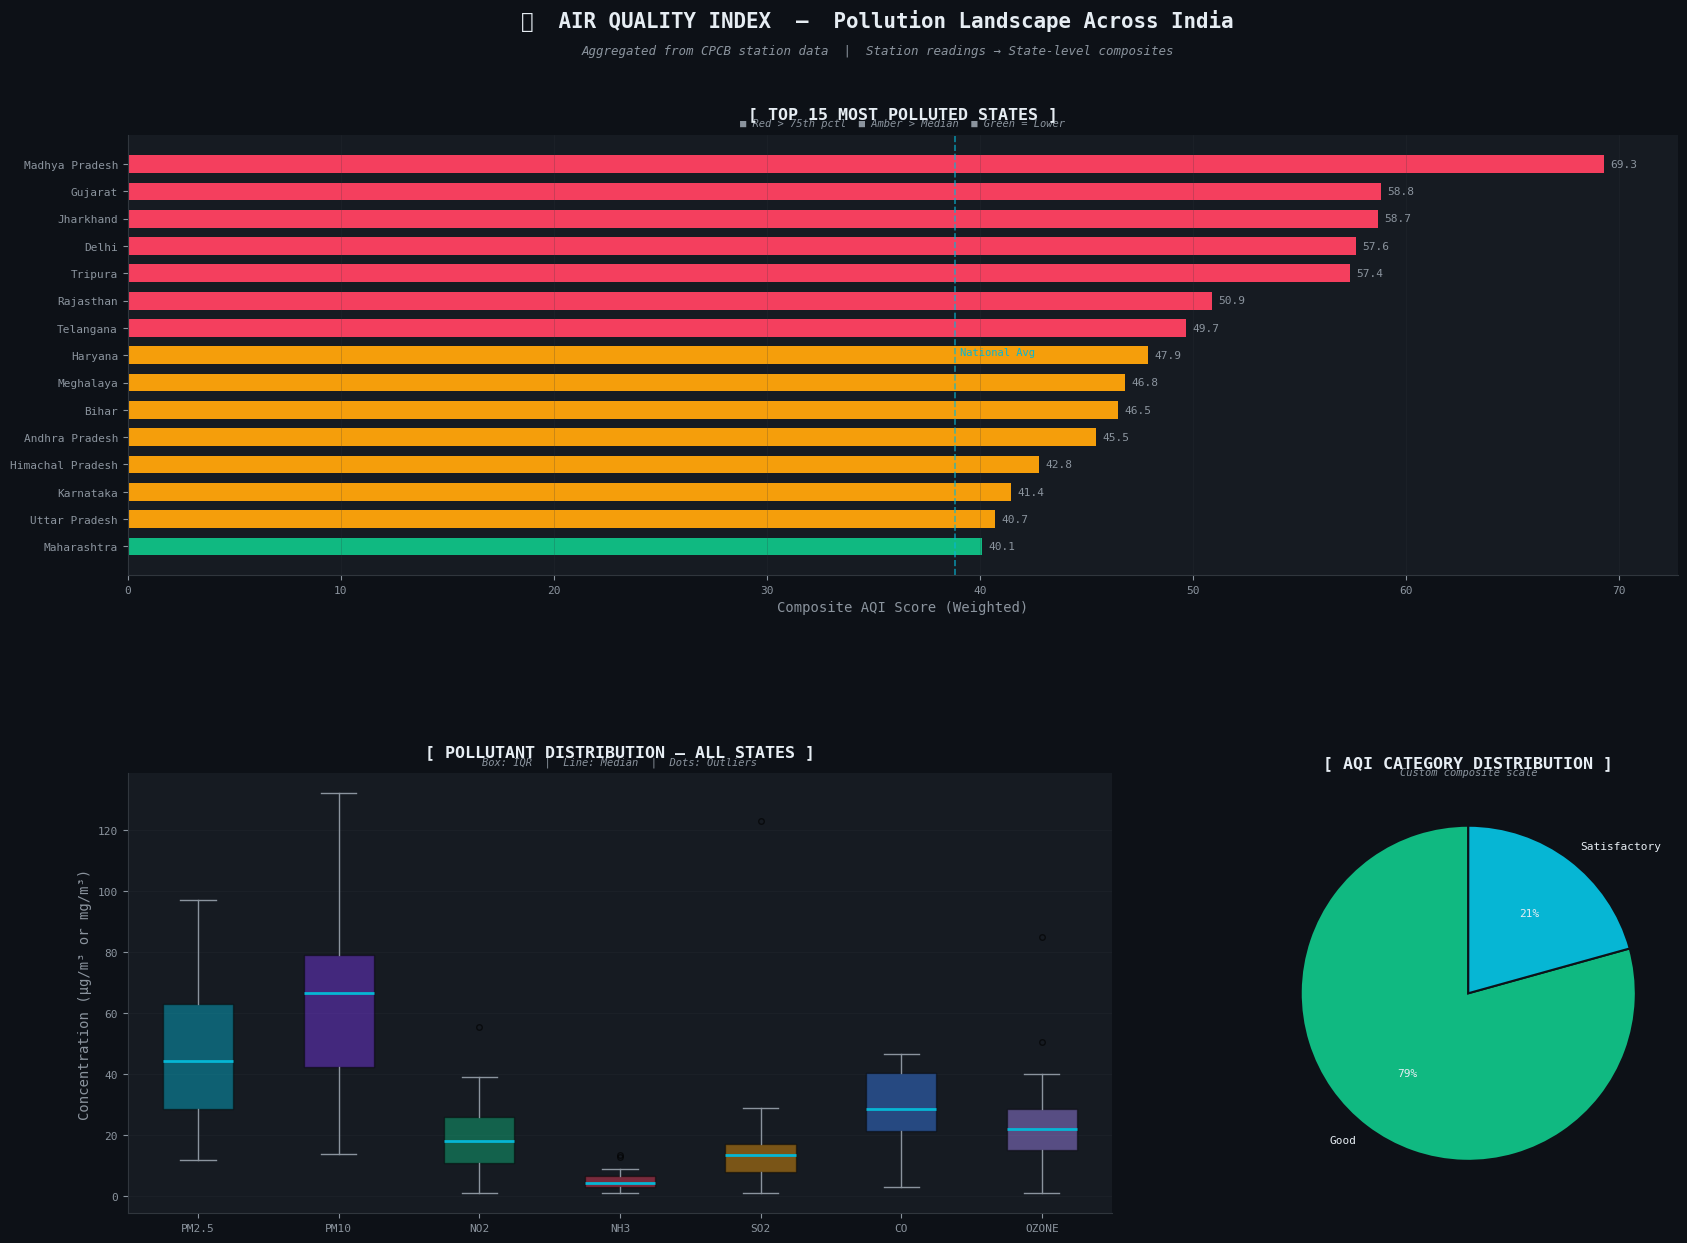

In [32]:
# ── EDA-1: AQI ────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 14), facecolor=DARK_BG)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

fig.text(0.5, 0.97, '🌫  AIR QUALITY INDEX  —  Pollution Landscape Across India',
         ha='center', va='top', fontsize=15, fontweight='bold',
         color=TEXT_PRI, fontfamily='monospace')
fig.text(0.5, 0.945, 'Aggregated from CPCB station data  |  Station readings → State-level composites',
         ha='center', va='top', fontsize=9, color=TEXT_SEC, style='italic')

ax1 = fig.add_subplot(gs[0, :])
top15 = aqi_pivot.nlargest(15, 'AQI_Composite').sort_values('AQI_Composite')
q75 = aqi_pivot['AQI_Composite'].quantile(0.75)
med = aqi_pivot['AQI_Composite'].median()
colors_bar = [ACCENT_ROSE if v > q75 else ACCENT_AMB if v > med
              else ACCENT_EMER for v in top15['AQI_Composite']]
bars = ax1.barh(top15['state'], top15['AQI_Composite'],
                color=colors_bar, edgecolor='none', height=0.65)
for bar, val in zip(bars, top15['AQI_Composite']):
    ax1.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
             f'{val:.1f}', va='center', fontsize=8, color=TEXT_SEC)
ax1.axvline(aqi_pivot['AQI_Composite'].mean(), color=ACCENT_CYAN,
            ls='--', lw=1.2, alpha=0.7)
ax1.text(aqi_pivot['AQI_Composite'].mean()+0.2, 0.5, 'National Avg',
         fontsize=7.5, color=ACCENT_CYAN, transform=ax1.get_xaxis_transform())
ax1.set_xlabel('Composite AQI Score (Weighted)')
styled_title(ax1, '[ TOP 15 MOST POLLUTED STATES ]',
             '■ Red > 75th pctl  ■ Amber > Median  ■ Green = Lower')
ax1.grid(axis='x', alpha=0.3)

poll_cols = [c for c in KEEP_POLLUTANTS if c in aqi_pivot.columns]
ax2 = fig.add_subplot(gs[1, :2])
data_box = [aqi_pivot[p].dropna().values for p in poll_cols]
bp = ax2.boxplot(data_box, labels=poll_cols, patch_artist=True,
                 medianprops={'color':ACCENT_CYAN,'linewidth':2},
                 whiskerprops={'color':TEXT_SEC}, capprops={'color':TEXT_SEC},
                 flierprops={'marker':'o','color':ACCENT_ROSE,'markersize':4,'alpha':0.6})
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color); patch.set_alpha(0.45)
ax2.set_ylabel('Concentration (µg/m³ or mg/m³)')
styled_title(ax2, '[ POLLUTANT DISTRIBUTION — ALL STATES ]',
             'Box: IQR  |  Line: Median  |  Dots: Outliers')
ax2.grid(axis='y', alpha=0.3)

ax3 = fig.add_subplot(gs[1, 2])
def aqi_cat(v):
    if v<=50: return 'Good'
    if v<=100: return 'Satisfactory'
    if v<=200: return 'Moderate'
    if v<=300: return 'Poor'
    return 'Very Poor'
cat_counts = aqi_pivot['AQI_Composite'].apply(aqi_cat).value_counts()
cat_colors = {'Good':ACCENT_EMER,'Satisfactory':ACCENT_CYAN,
              'Moderate':ACCENT_AMB,'Poor':ACCENT_ROSE,'Very Poor':'#9f1239'}
ax3.pie(cat_counts.values,
        labels=cat_counts.index,
        colors=[cat_colors.get(k,ACCENT_BLUE) for k in cat_counts.index],
        autopct='%1.0f%%', startangle=90,
        textprops={'color':TEXT_PRI,'fontsize':8},
        wedgeprops={'edgecolor':DARK_BG,'linewidth':1.5})
styled_title(ax3, '[ AQI CATEGORY DISTRIBUTION ]', 'Custom composite scale')

plt.savefig('output_aqi_eda.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

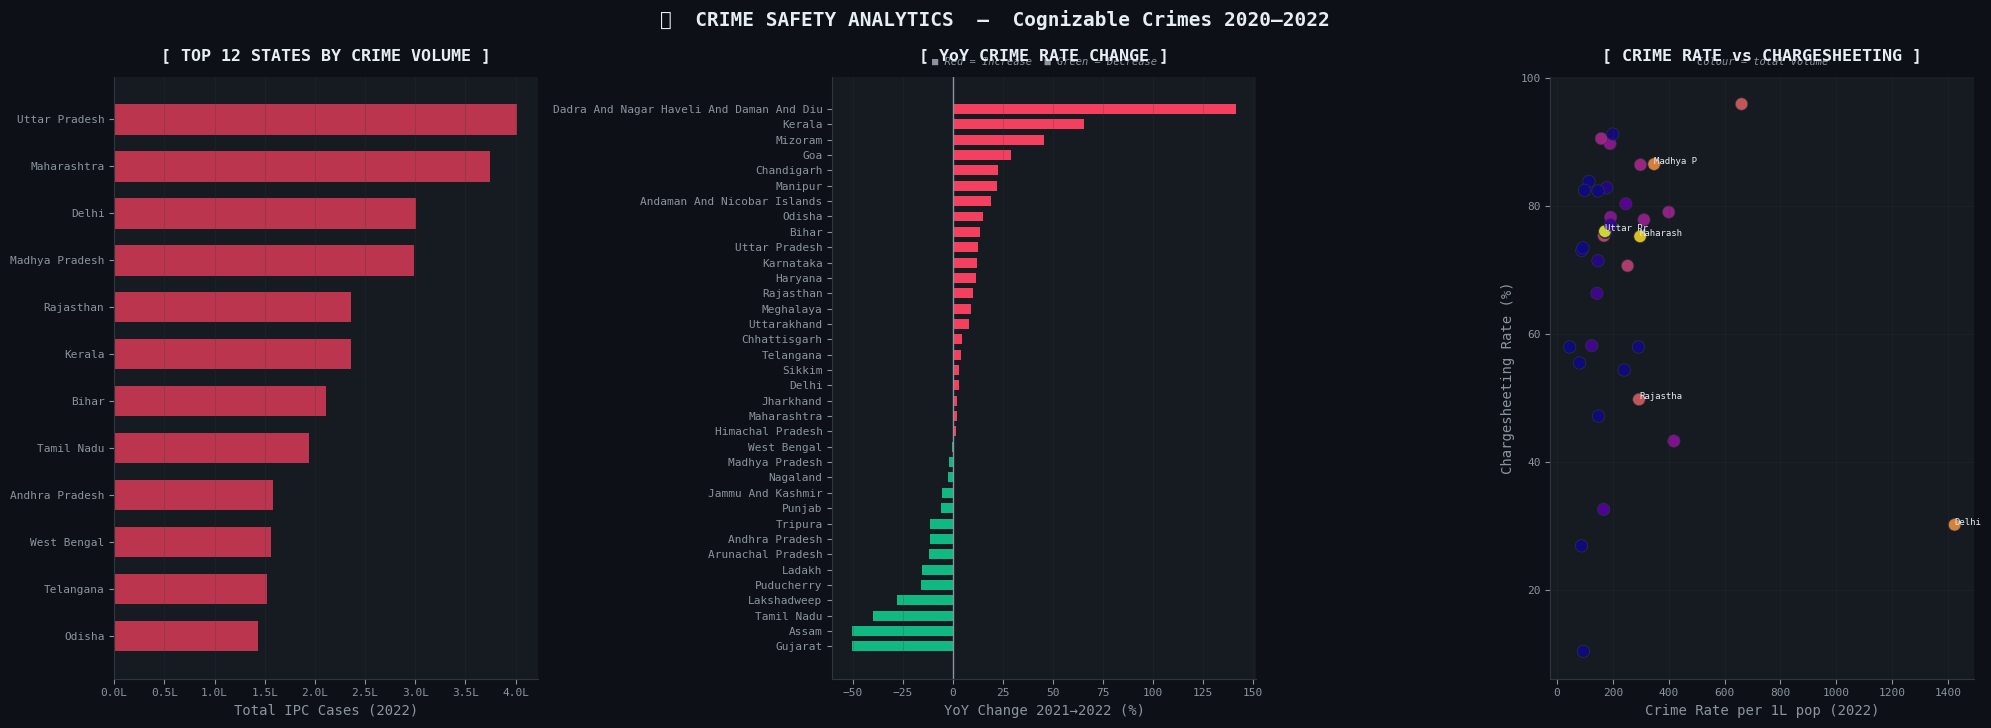

In [33]:
# ── EDA-2: CRIME ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7), facecolor=DARK_BG)
fig.text(0.5, 1.01, '🔒  CRIME SAFETY ANALYTICS  —  Cognizable Crimes 2020–2022',
         ha='center', fontsize=14, fontweight='bold', color=TEXT_PRI, fontfamily='monospace')

ax = axes[0]
top_crime = crime.nlargest(12, 'crime_2022').sort_values('crime_2022')
ax.barh(top_crime['state'], top_crime['crime_2022'],
        color=ACCENT_ROSE, alpha=0.75, edgecolor='none', height=0.65)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e5:.1f}L'))
ax.set_xlabel('Total IPC Cases (2022)')
styled_title(ax, '[ TOP 12 STATES BY CRIME VOLUME ]', '')
ax.grid(axis='x', alpha=0.3)

ax = axes[1]
yoy_sorted = crime.sort_values('crime_yoy_pct')
colors_yoy = [ACCENT_ROSE if v>0 else ACCENT_EMER for v in yoy_sorted['crime_yoy_pct']]
ax.barh(yoy_sorted['state'], yoy_sorted['crime_yoy_pct'],
        color=colors_yoy, edgecolor='none', height=0.65)
ax.axvline(0, color=TEXT_SEC, lw=1)
ax.set_xlabel('YoY Change 2021→2022 (%)')
styled_title(ax, '[ YoY CRIME RATE CHANGE ]', '■ Red = Increase  ■ Green = Decrease')
ax.grid(axis='x', alpha=0.3)

ax = axes[2]
ax.scatter(crime['crime_rate_2022'], crime['chargesheeting_rate'],
           c=crime['crime_2022'], cmap='plasma', s=80,
           edgecolors=BORDER, linewidths=0.5, alpha=0.85)
for _, row in crime.nlargest(5,'crime_2022').iterrows():
    ax.annotate(row['state'][:8], (row['crime_rate_2022'], row['chargesheeting_rate']),
                fontsize=6.5, color=TEXT_PRI)
ax.set_xlabel('Crime Rate per 1L pop (2022)')
ax.set_ylabel('Chargesheeting Rate (%)')
styled_title(ax, '[ CRIME RATE vs CHARGESHEETING ]', 'Colour = total volume')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('output_crime_eda.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

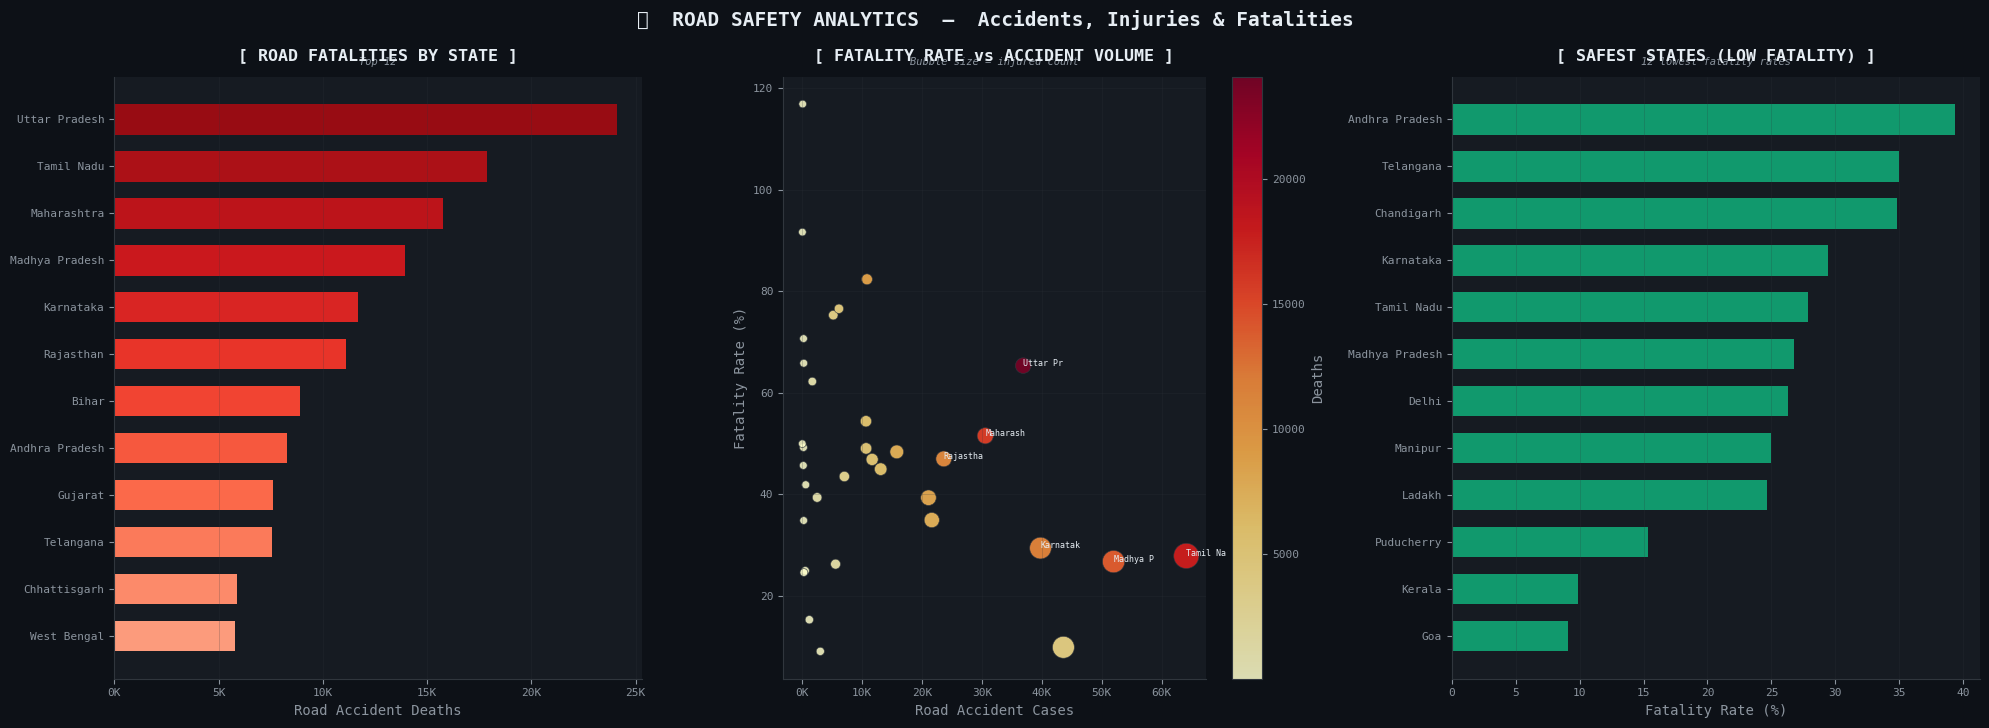

In [34]:
# ── EDA-3: ROAD ACCIDENTS ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7), facecolor=DARK_BG)
fig.text(0.5, 1.01, '🚗  ROAD SAFETY ANALYTICS  —  Accidents, Injuries & Fatalities',
         ha='center', fontsize=14, fontweight='bold', color=TEXT_PRI, fontfamily='monospace')

ax = axes[0]
top_d = acc.nlargest(12,'road_deaths').sort_values('road_deaths')
gradient = plt.cm.Reds(np.linspace(0.35, 0.9, len(top_d)))
ax.barh(top_d['state'], top_d['road_deaths'],
        color=gradient, edgecolor='none', height=0.65)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}K'))
ax.set_xlabel('Road Accident Deaths')
styled_title(ax, '[ ROAD FATALITIES BY STATE ]', 'Top 12')
ax.grid(axis='x', alpha=0.3)

ax = axes[1]
sc = ax.scatter(acc['road_cases'], acc['road_fatality_rate'],
                c=acc['road_deaths'], cmap='YlOrRd',
                s=acc['road_injured']/acc['road_injured'].max()*300+30,
                edgecolors=BORDER, linewidths=0.5, alpha=0.85)
for _, row in acc.nlargest(6,'road_deaths').iterrows():
    ax.annotate(row['state'][:8], (row['road_cases'], row['road_fatality_rate']),
                fontsize=6, color=TEXT_PRI)
plt.colorbar(sc, ax=ax, label='Deaths')
ax.set_xlabel('Road Accident Cases')
ax.set_ylabel('Fatality Rate (%)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}K'))
styled_title(ax, '[ FATALITY RATE vs ACCIDENT VOLUME ]', 'Bubble size = injured count')
ax.grid(alpha=0.3)

ax = axes[2]
safe_top = acc.nsmallest(12,'road_fatality_rate').sort_values('road_fatality_rate')
ax.barh(safe_top['state'], safe_top['road_fatality_rate'],
        color=ACCENT_EMER, alpha=0.8, edgecolor='none', height=0.65)
ax.set_xlabel('Fatality Rate (%)')
styled_title(ax, '[ SAFEST STATES (LOW FATALITY) ]', '12 lowest fatality rates')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('output_accidents_eda.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

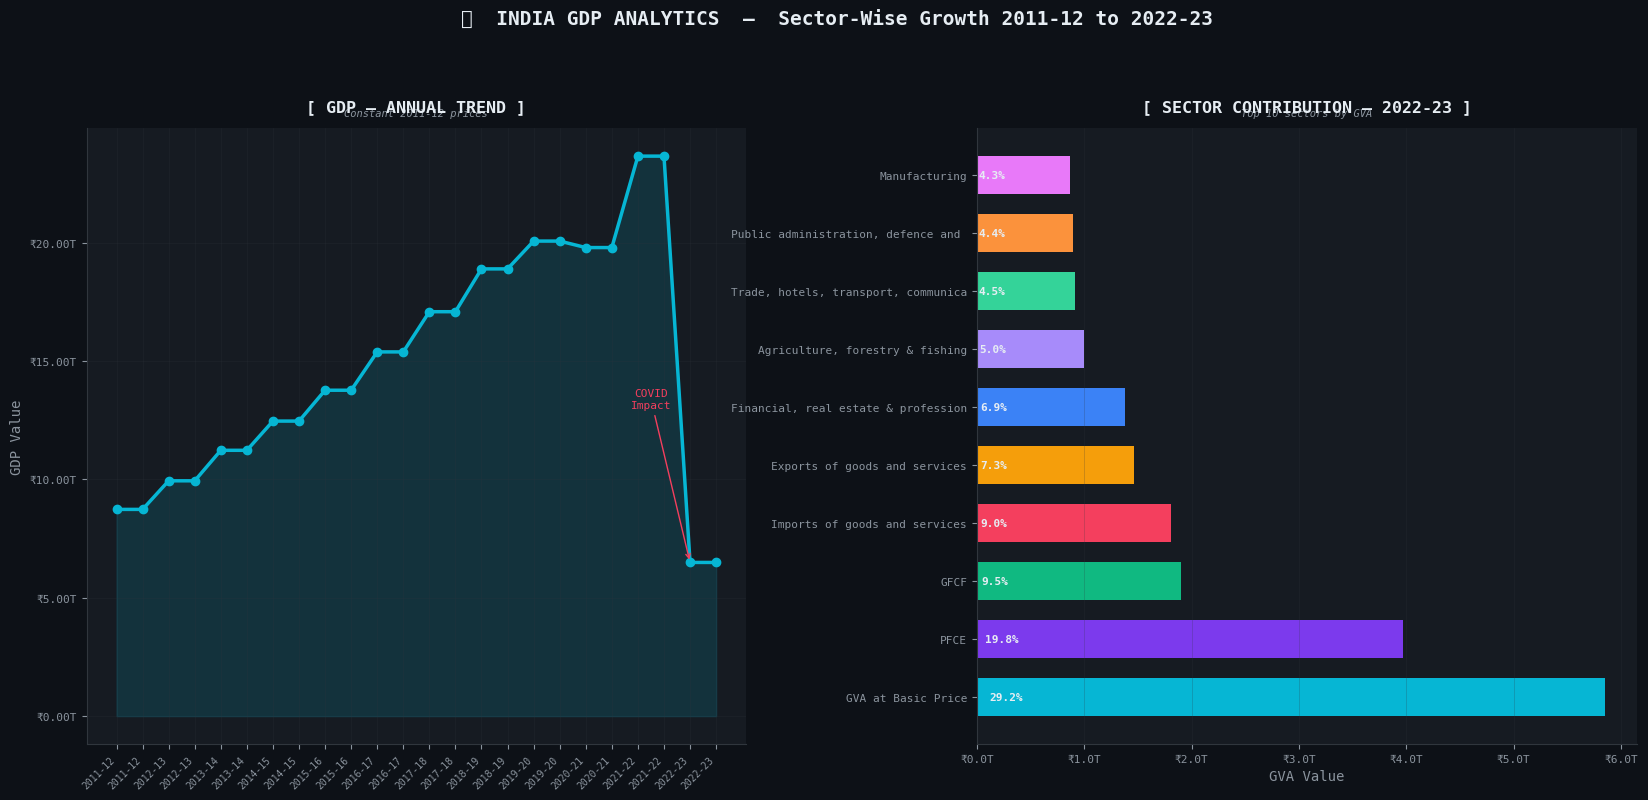

In [35]:
# ── EDA-4: GDP ────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 8), facecolor=DARK_BG)
gs  = gridspec.GridSpec(1, 2, figure=fig, hspace=0.45, wspace=0.35)
fig.text(0.5, 1.01, '📈  INDIA GDP ANALYTICS  —  Sector-Wise Growth 2011-12 to 2022-23',
         ha='center', fontsize=14, fontweight='bold', color=TEXT_PRI, fontfamily='monospace')

ax1 = fig.add_subplot(gs[0, 0])
if not gdp_total.empty:
    gdp_t = gdp_total.sort_values('year')
    ax1.fill_between(range(len(gdp_t)), gdp_t['gdp_value_cr'],
                     alpha=0.15, color=ACCENT_CYAN)
    ax1.plot(range(len(gdp_t)), gdp_t['gdp_value_cr'],
             color=ACCENT_CYAN, lw=2.5, marker='o', markersize=6)
    ax1.set_xticks(range(len(gdp_t)))
    ax1.set_xticklabels(gdp_t['year'], rotation=45, ha='right', fontsize=7)
    # annotate COVID dip
    idx_min = gdp_t['gdp_value_cr'].idxmin()
    pos     = gdp_t.index.get_loc(idx_min)
    ax1.annotate('COVID\nImpact',
                 xy=(pos, gdp_t.loc[idx_min,'gdp_value_cr']),
                 xytext=(max(pos-1.5,0), gdp_t['gdp_value_cr'].max()*0.55),
                 arrowprops={'arrowstyle':'->','color':ACCENT_ROSE},
                 color=ACCENT_ROSE, fontsize=8, ha='center')
    ax1.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x,_: f'₹{x/1e6:.2f}T'))
else:
    ax1.text(0.5, 0.5, 'GDP total row not found\nin this CSV.',
             ha='center', va='center', color=ACCENT_AMB, fontsize=11,
             transform=ax1.transAxes)
styled_title(ax1, '[ GDP — ANNUAL TREND ]', 'Constant 2011-12 prices')
ax1.set_ylabel('GDP Value')
ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
latest_yr   = gdp_sector['year'].max()
latest_data = (gdp_sector[gdp_sector['year']==latest_yr]
               .sort_values('gdp_value_cr', ascending=False).head(10))
total_val   = latest_data['gdp_value_cr'].sum()
latest_data = latest_data.copy()
latest_data['share'] = (latest_data['gdp_value_cr']/total_val*100).round(1)
def short(s):
    import re
    return re.sub(r'^\d+\.\s*','',str(s))[:35]
latest_data['short'] = latest_data['sector'].apply(short)
bars = ax2.barh(latest_data['short'], latest_data['gdp_value_cr'],
                color=PALETTE[:len(latest_data)], edgecolor='none', height=0.65)
for bar, pct in zip(bars, latest_data['share']):
    ax2.text(bar.get_width()*0.02, bar.get_y()+bar.get_height()/2,
             f'{pct:.1f}%', va='center', fontsize=8,
             color=TEXT_PRI, fontweight='bold')
ax2.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'₹{x/1e6:.1f}T'))
styled_title(ax2, f'[ SECTOR CONTRIBUTION — {latest_yr} ]', 'Top 10 sectors by GVA')
ax2.set_xlabel('GVA Value')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('output_gdp_eda.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

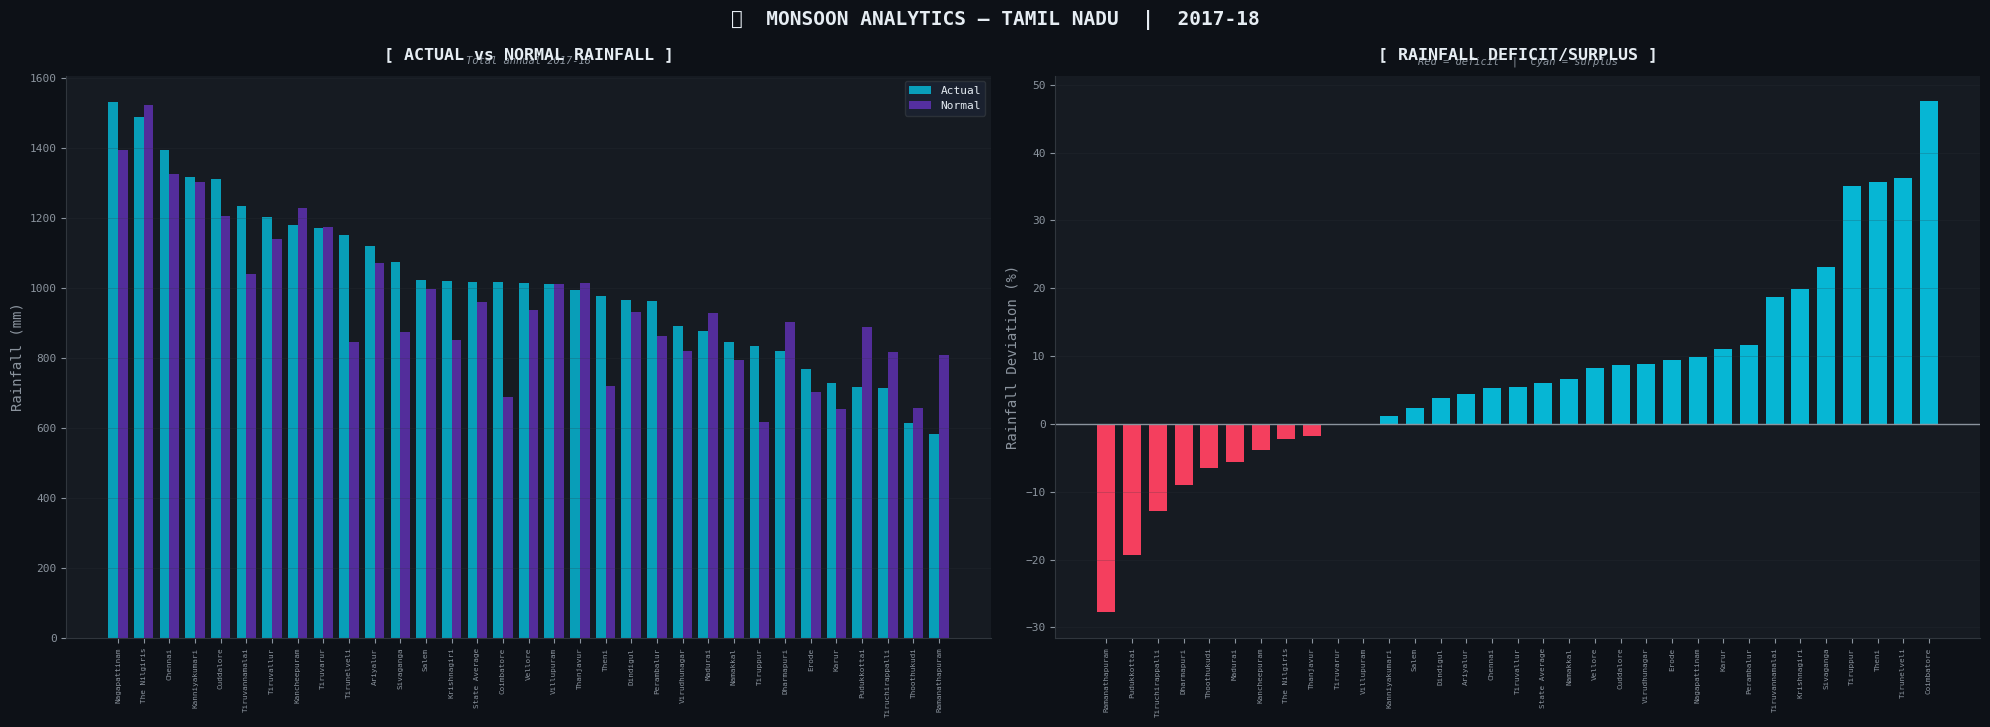

In [36]:
# ── EDA-5: RAINFALL (Tamil Nadu 2017-18) ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 7), facecolor=DARK_BG)
fig.text(0.5, 1.01, '🌧  MONSOON ANALYTICS — TAMIL NADU  |  2017-18',
         ha='center', fontsize=14, fontweight='bold', color=TEXT_PRI, fontfamily='monospace')

ax = axes[0]
rain_s = rain.sort_values('total_actual', ascending=False)
x = np.arange(len(rain_s))
w = 0.38
ax.bar(x-w/2, rain_s['total_actual'],  w, label='Actual',
       color=ACCENT_CYAN, alpha=0.85, edgecolor='none')
ax.bar(x+w/2, rain_s['total_normal'], w, label='Normal',
       color=ACCENT_PUR, alpha=0.6, edgecolor='none')
ax.set_xticks(x)
ax.set_xticklabels(rain_s['district'], rotation=90, fontsize=5.5)
ax.set_ylabel('Rainfall (mm)')
ax.legend()
styled_title(ax, '[ ACTUAL vs NORMAL RAINFALL ]', 'Total annual 2017-18')
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
rain_d = rain.sort_values('deficit_pct')
c_rain = [ACCENT_ROSE if v<0 else ACCENT_CYAN for v in rain_d['deficit_pct']]
ax.bar(range(len(rain_d)), rain_d['deficit_pct'],
       color=c_rain, edgecolor='none', width=0.7)
ax.axhline(0, color=TEXT_SEC, lw=1)
ax.set_xticks(range(len(rain_d)))
ax.set_xticklabels(rain_d['district'], rotation=90, fontsize=5.5)
ax.set_ylabel('Rainfall Deviation (%)')
styled_title(ax, '[ RAINFALL DEFICIT/SURPLUS ]', 'Red = deficit  |  Cyan = surplus')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('output_rainfall_eda.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

---
## 🔗 Phase 5 · Data Fusion — Building the Unified State-Level Dataset

In [37]:
# ── State-name normalisation ──────────────────────────────────────────────────
CORRECTIONS = {
    'Jammu And Kashmir':                        'Jammu & Kashmir',
    'Jammu & Kashmir':                          'Jammu & Kashmir',
    'J&K':                                      'Jammu & Kashmir',
    'Andaman And Nicobar':                      'Andaman & Nicobar Islands',
    'Andaman & Nicobar':                        'Andaman & Nicobar Islands',
    'D & N Haveli':                             'Dadra And Nagar Haveli And Daman And Diu',
    'Dadra And Nagar Haveli':                   'Dadra And Nagar Haveli And Daman And Diu',
    'The Dadra And Nagar Haveli And Daman And Diu':
                                                'Dadra And Nagar Haveli And Daman And Diu',
    'Tamilnadu':                                'Tamil Nadu',
    'Orissa':                                   'Odisha',
    'Uttaranchal':                              'Uttarakhand',
    'Delhi':                                    'Delhi',
    'Nct Of Delhi':                             'Delhi',
}

def norm_state(s):
    s = str(s).strip().title()
    return CORRECTIONS.get(s, s)

aqi_pivot['state'] = aqi_pivot['state'].apply(norm_state)
crime['state']     = crime['state'].apply(norm_state)
acc['state']       = acc['state'].apply(norm_state)
pop_state['state'] = pop_state['state'].apply(norm_state)

# ── Select columns ────────────────────────────────────────────────────────────
poll_extra = [c for c in ['PM2.5','PM10','NO2','SO2','CO'] if c in aqi_pivot.columns]
aqi_sel   = aqi_pivot[['state','AQI_Composite'] + poll_extra]
crime_sel = crime[['state','crime_2022','crime_rate_2022',
                   'chargesheeting_rate','crime_yoy_pct']]
acc_sel   = acc[['state','road_cases','road_deaths',
                 'road_fatality_rate','total_acc_deaths']]
pop_sel   = pop_state[['state','total_post_offices',
                        'total_districts','infra_density']]

# ── Outer merge on state key ──────────────────────────────────────────────────
fused = (aqi_sel
         .merge(crime_sel, on='state', how='outer')
         .merge(acc_sel,   on='state', how='outer')
         .merge(pop_sel,   on='state', how='outer'))

# Attach national GDP growth as a scalar context feature
if not gdp_total.empty:
    latest_gdp = gdp_total.sort_values('year').dropna(subset=['growth_rate_pct'])
    if not latest_gdp.empty:
        fused['national_gdp_growth_pct'] = latest_gdp['growth_rate_pct'].iloc[-1]

# Attach TN rainfall as state-specific data
tn_avg_actual  = rain['total_actual'].mean()
tn_avg_deficit = rain['deficit_pct'].mean()
fused.loc[fused['state']=='Tamil Nadu', 'rainfall_actual_mm']   = tn_avg_actual
fused.loc[fused['state']=='Tamil Nadu', 'rainfall_deficit_pct'] = tn_avg_deficit

section_header('Fused Dataset Shape', '🔗')
print(f'  Rows: {fused.shape[0]}  |  Columns: {fused.shape[1]}')
miss = fused.isnull().sum()
miss_pct = (miss / len(fused) * 100).round(1)
print(pd.DataFrame({'Missing': miss, 'Missing%': miss_pct})[miss>0].to_string())


────────────────────────────────────────────────────────────────────────
  🔗  Fused Dataset Shape
────────────────────────────────────────────────────────────────────────

  Rows: 36  |  Columns: 21
                      Missing  Missing%
AQI_Composite               7      19.4
PM2.5                       8      22.2
PM10                        9      25.0
NO2                         7      19.4
SO2                         7      19.4
CO                          7      19.4
road_cases                  2       5.6
road_deaths                 2       5.6
road_fatality_rate          2       5.6
total_acc_deaths            2       5.6
rainfall_actual_mm         35      97.2
rainfall_deficit_pct       35      97.2


In [38]:
# ── Post-Fusion Imputation ────────────────────────────────────────────────────
# FIX: use assignment (fused[col] = ...) instead of inplace=True on slice
#      inplace=True silently fails on column slices in pandas 2.x
for col in fused.select_dtypes(include=np.number).columns:
    fused[col] = fused[col].fillna(fused[col].median())

fused = fused.dropna(subset=['state']).reset_index(drop=True)

# Remove any duplicate state rows (keep first)
fused = fused.drop_duplicates(subset='state', keep='first').reset_index(drop=True)

section_header('Post-Imputation Check', '✅')
print(f'  Final dataset: {fused.shape[0]} states × {fused.shape[1]} features')
print(f'  Remaining NaNs: {fused.isnull().sum().sum()}')
print()
print(fused[['state','AQI_Composite','crime_rate_2022','road_fatality_rate','infra_density']]
      .sort_values('AQI_Composite', ascending=False).head(10).to_string(index=False))


────────────────────────────────────────────────────────────────────────
  ✅  Post-Imputation Check
────────────────────────────────────────────────────────────────────────

  Final dataset: 36 states × 21 features
  Remaining NaNs: 0

         state  AQI_Composite  crime_rate_2022  road_fatality_rate  infra_density
Madhya Pradesh          69.29            347.6               26.78         197.54
       Gujarat          58.81            189.8               48.39         267.91
     Jharkhand          58.70            124.5               75.32         191.00
         Delhi          57.65           1424.1               26.28          50.00
       Tripura          57.35             88.7               41.91          90.38
     Rajasthan          50.89            293.5               47.01         334.30
     Telangana          49.68            400.1               34.96         189.48
       Haryana          47.88            418.6               49.07         123.00
     Meghalaya          4

---
## ⚙️ Phase 6 · Feature Engineering — Risk, Safety & Development Indices

In [39]:
# ── Normalisation helper ──────────────────────────────────────────────────────
def normalise(series, inverse=False):
    mn, mx = series.min(), series.max()
    if mx == mn:
        return pd.Series([0.5]*len(series), index=series.index)
    n = (series - mn) / (mx - mn)
    return 1 - n if inverse else n

# ── 1. Pollution Risk Score (PRS) ─────────────────────────────────────────────
pm25_col = 'PM2.5' if 'PM2.5' in fused.columns else 'AQI_Composite'
no2_col  = 'NO2'   if 'NO2'   in fused.columns else 'AQI_Composite'
fused['PRS'] = (
    normalise(fused['AQI_Composite']) * 0.60 +
    normalise(fused[pm25_col])        * 0.25 +
    normalise(fused[no2_col])         * 0.15
).round(4)

# ── 2. Safety Index (SI) ──────────────────────────────────────────────────────
fused['SI'] = (
    normalise(fused['crime_rate_2022'],    inverse=True) * 0.40 +
    normalise(fused['road_fatality_rate'], inverse=True) * 0.35 +
    normalise(fused['chargesheeting_rate'])              * 0.25
).round(4)

# ── 3. Development Index (DI) ─────────────────────────────────────────────────
fused['DI'] = (
    normalise(fused['infra_density'])      * 0.50 +
    normalise(fused['total_post_offices']) * 0.30 +
    normalise(fused['total_districts'])    * 0.20
).round(4)

# ── 4. Urban Risk Index (URI) ─────────────────────────────────────────────────
fused['URI'] = (
    fused['PRS']      * 0.40 +
    (1-fused['SI'])   * 0.35 +
    (1-fused['DI'])   * 0.25
).round(4)

def risk_tier(v):
    if v >= 0.65: return 'CRITICAL'
    if v >= 0.50: return 'HIGH'
    if v >= 0.35: return 'MODERATE'
    return 'LOW'

fused['Risk_Tier'] = fused['URI'].apply(risk_tier)

section_header('Feature Engineering — Indices Computed', '⚙️')
print(fused[['state','PRS','SI','DI','URI','Risk_Tier']]
      .sort_values('URI', ascending=False).to_string(index=False))


────────────────────────────────────────────────────────────────────────
  ⚙️  Feature Engineering — Indices Computed
────────────────────────────────────────────────────────────────────────

                                   state    PRS     SI     DI    URI Risk_Tier
                                   Delhi 0.7472 0.3520 0.0859 0.7542  CRITICAL
                                 Tripura 0.7901 0.8140 0.1311 0.5984      HIGH
                               Jharkhand 0.7824 0.6517 0.3644 0.5938      HIGH
                                 Haryana 0.6017 0.6080 0.2428 0.5672      HIGH
                          Madhya Pradesh 0.9248 0.8275 0.5432 0.5445      HIGH
                               Meghalaya 0.4293 0.6017 0.1353 0.5273      HIGH
                       Arunachal Pradesh 0.4338 0.6275 0.1302 0.5213      HIGH
                                 Manipur 0.4338 0.6841 0.1021 0.5086      HIGH
                             Lakshadweep 0.4338 0.7877 0.0000 0.4978  MODERATE
Dadra And Nagar H

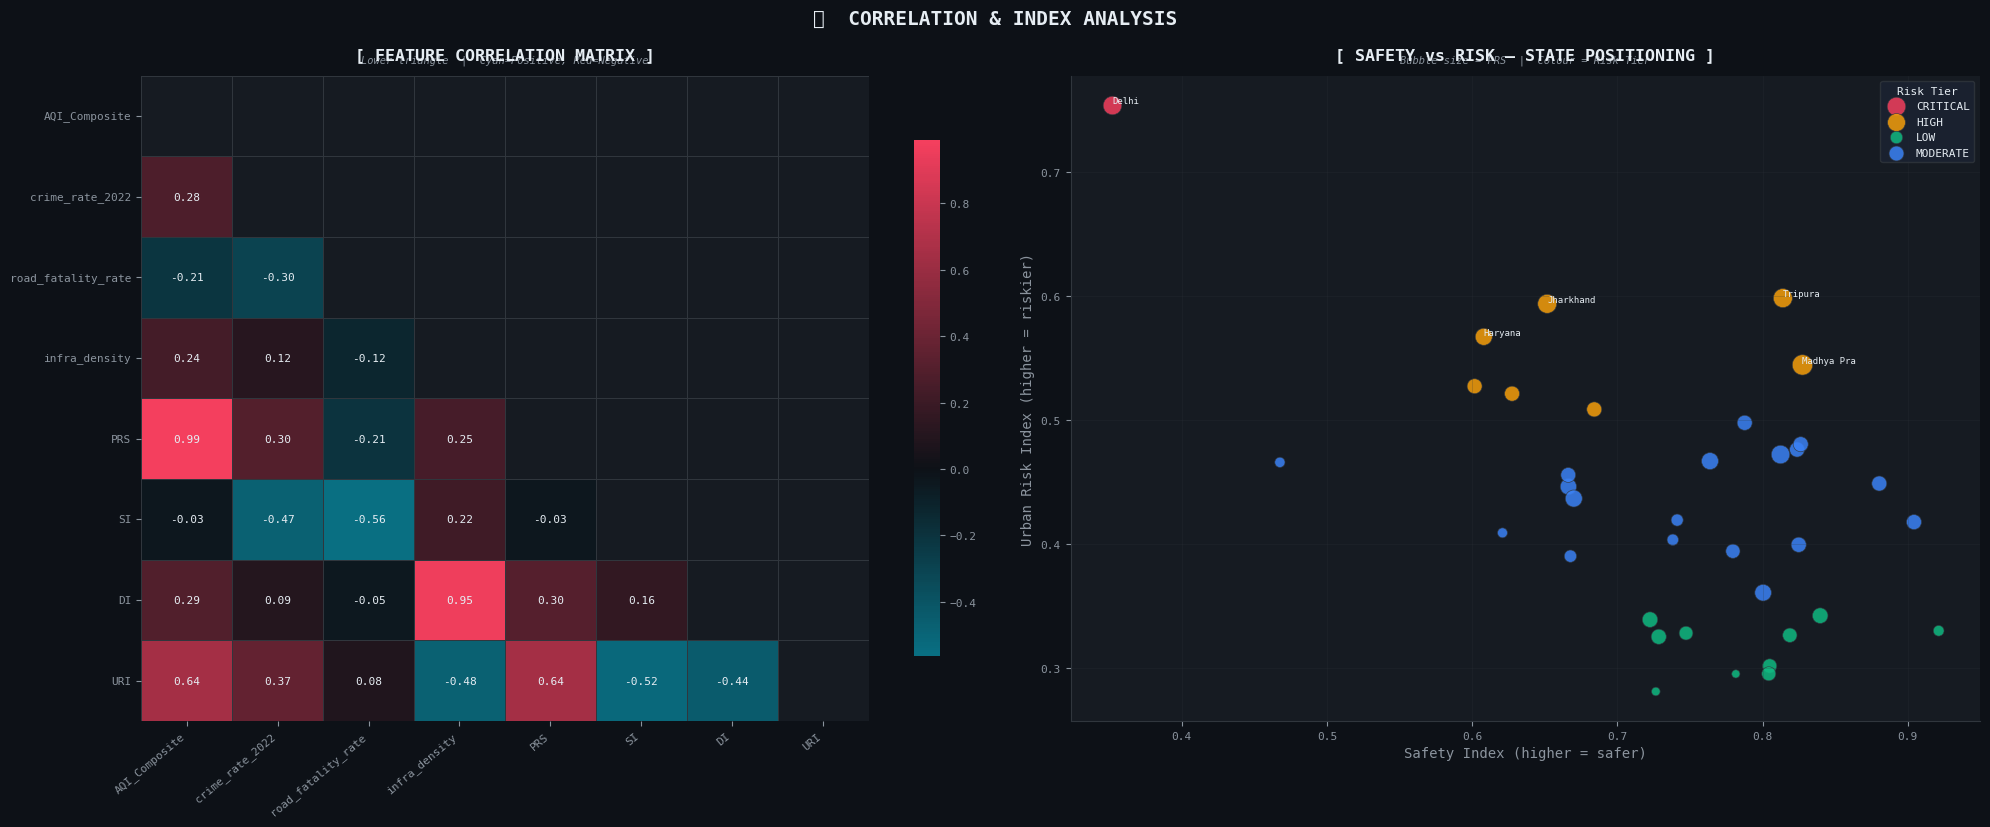

In [18]:
# ── Correlation & Index Scatter ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 8), facecolor=DARK_BG)
fig.text(0.5, 1.01, '🔬  CORRELATION & INDEX ANALYSIS',
         ha='center', fontsize=14, fontweight='bold', color=TEXT_PRI, fontfamily='monospace')

ax = axes[0]
corr_features = [c for c in ['AQI_Composite','crime_rate_2022','road_fatality_rate',
                              'infra_density','PRS','SI','DI','URI'] if c in fused.columns]
corr_mat = fused[corr_features].corr()
cmap_div = LinearSegmentedColormap.from_list(
    'urbanscope', ['#06b6d4', DARK_BG, '#f43f5e'], N=256)
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, ax=ax, mask=mask, cmap=cmap_div, center=0,
            annot=True, fmt='.2f', annot_kws={'size':8,'color':TEXT_PRI},
            linewidths=0.5, linecolor=BORDER, cbar_kws={'shrink':0.8})
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
styled_title(ax, '[ FEATURE CORRELATION MATRIX ]',
             'Lower triangle  |  Cyan=Positive, Red=Negative')

ax = axes[1]
tier_colors = {'CRITICAL':ACCENT_ROSE,'HIGH':ACCENT_AMB,
               'MODERATE':ACCENT_BLUE,'LOW':ACCENT_EMER}
for tier, grp in fused.groupby('Risk_Tier'):
    ax.scatter(grp['SI'], grp['URI'], label=tier,
               color=tier_colors[tier],
               s=grp['PRS']*200+30, edgecolors=BORDER, linewidths=0.5, alpha=0.85)
for _, row in fused.nlargest(5,'URI').iterrows():
    ax.annotate(row['state'][:10], (row['SI'], row['URI']),
                fontsize=6.5, color=TEXT_PRI, ha='left', va='bottom')
ax.set_xlabel('Safety Index (higher = safer)')
ax.set_ylabel('Urban Risk Index (higher = riskier)')
ax.legend(title='Risk Tier', title_fontsize=8)
styled_title(ax, '[ SAFETY vs RISK — STATE POSITIONING ]',
             'Bubble size = PRS  |  Colour = Risk Tier')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('output_correlation.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

---
## 🤖 Phase 7 · Machine Learning — Predictive Models & Clustering

In [40]:
# ── ML MODEL: Predict URI from raw (non-derived) features ─────────────────────
# NOTE: We use only RAW input features — not PRS/SI/DI — to avoid circular prediction.
ML_FEATURES = [f for f in ['AQI_Composite','crime_rate_2022','road_fatality_rate',
                            'chargesheeting_rate','infra_density','total_post_offices']
               if f in fused.columns]
TARGET = 'URI'

fused_ml = fused[ML_FEATURES + [TARGET]].dropna().reset_index(drop=True)
X = fused_ml[ML_FEATURES].values
y = fused_ml[TARGET].values

section_header('ML Setup', '🤖')
print(f'  Training samples: {len(X)}  |  Features: {len(ML_FEATURES)}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42)

ss = StandardScaler()
X_train_s = ss.fit_transform(X_train)
X_test_s  = ss.transform(X_test)

# ── Random Forest ─────────────────────────────────────────────────────────────
rf = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42,
                            min_samples_leaf=2)
rf.fit(X_train_s, y_train)
y_pred_rf = rf.predict(X_test_s)

# ── Gradient Boosting ─────────────────────────────────────────────────────────
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                max_depth=4, random_state=42)
gb.fit(X_train_s, y_train)
y_pred_gb = gb.predict(X_test_s)

# ── Ridge Regression ──────────────────────────────────────────────────────────
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_s, y_train)
y_pred_ridge = ridge.predict(X_test_s)

# ── Cross-validation (more robust for small N) ────────────────────────────────
cv_rf  = cross_val_score(rf,    X_train_s, y_train, cv=5, scoring='r2')
cv_gb  = cross_val_score(gb,    X_train_s, y_train, cv=5, scoring='r2')
cv_rdg = cross_val_score(ridge, X_train_s, y_train, cv=5, scoring='r2')

print('\n  Model         | Test R²  | Test MAE | CV R² (5-fold mean)')
print('  ' + '-'*60)
for name, yp, cv in [('Random Forest', y_pred_rf, cv_rf),
                     ('Gradient Boost', y_pred_gb, cv_gb),
                     ('Ridge',          y_pred_ridge, cv_rdg)]:
    r2  = r2_score(y_test, yp)
    mae = mean_absolute_error(y_test, yp)
    print(f'  {name:<16}| {r2:7.4f}  | {mae:8.4f} | {cv.mean():.4f} ± {cv.std():.4f}')


────────────────────────────────────────────────────────────────────────
  🤖  ML Setup
────────────────────────────────────────────────────────────────────────

  Training samples: 36  |  Features: 6

  Model         | Test R²  | Test MAE | CV R² (5-fold mean)
  ------------------------------------------------------------
  Random Forest   |  0.5680  |   0.0638 | 0.4593 ± 0.3152
  Gradient Boost  |  0.5888  |   0.0637 | 0.3878 ± 0.2945
  Ridge           |  0.9783  |   0.0171 | 0.9395 ± 0.0228


In [41]:
# ── K-Means Clustering (on raw features, not derived indices) ─────────────────
# FIX: cluster on raw domain features, not URI/PRS/SI/DI (which are circular)
cluster_feats = [f for f in ['AQI_Composite','crime_rate_2022',
                              'road_fatality_rate','infra_density']
                 if f in fused.columns]
X_cl   = fused[cluster_feats].fillna(fused[cluster_feats].median()).values
X_cl_s = StandardScaler().fit_transform(X_cl)

# Elbow method
inertias = []
K_range  = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cl_s)
    inertias.append(km.inertia_)

OPTIMAL_K = 4
km_final  = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
fused['Cluster'] = km_final.fit_predict(X_cl_s)

pca = PCA(n_components=2)
pca_coords = pca.fit_transform(X_cl_s)
fused['PC1'] = pca_coords[:,0]
fused['PC2'] = pca_coords[:,1]

section_header('K-Means Clustering', '🔵')
print(f'  Optimal K: {OPTIMAL_K}  |  Features used: {cluster_feats}')
for c in range(OPTIMAL_K):
    states = fused[fused['Cluster']==c]['state'].tolist()
    print(f'  Cluster {c}: {states}')


────────────────────────────────────────────────────────────────────────
  🔵  K-Means Clustering
────────────────────────────────────────────────────────────────────────

  Optimal K: 4  |  Features used: ['AQI_Composite', 'crime_rate_2022', 'road_fatality_rate', 'infra_density']
  Cluster 0: ['Arunachal Pradesh', 'Bihar', 'Jharkhand', 'Meghalaya', 'Mizoram', 'Nagaland', 'Punjab', 'Uttar Pradesh', 'Uttarakhand']
  Cluster 1: ['Andhra Pradesh', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Odisha', 'Rajasthan', 'Tamil Nadu', 'Telangana', 'West Bengal']
  Cluster 2: ['Andaman And Nicobar Islands', 'Assam', 'Chandigarh', 'Chhattisgarh', 'Dadra And Nagar Haveli And Daman And Diu', 'Goa', 'Jammu & Kashmir', 'Ladakh', 'Lakshadweep', 'Manipur', 'Puducherry', 'Sikkim', 'Tripura']
  Cluster 3: ['Delhi']


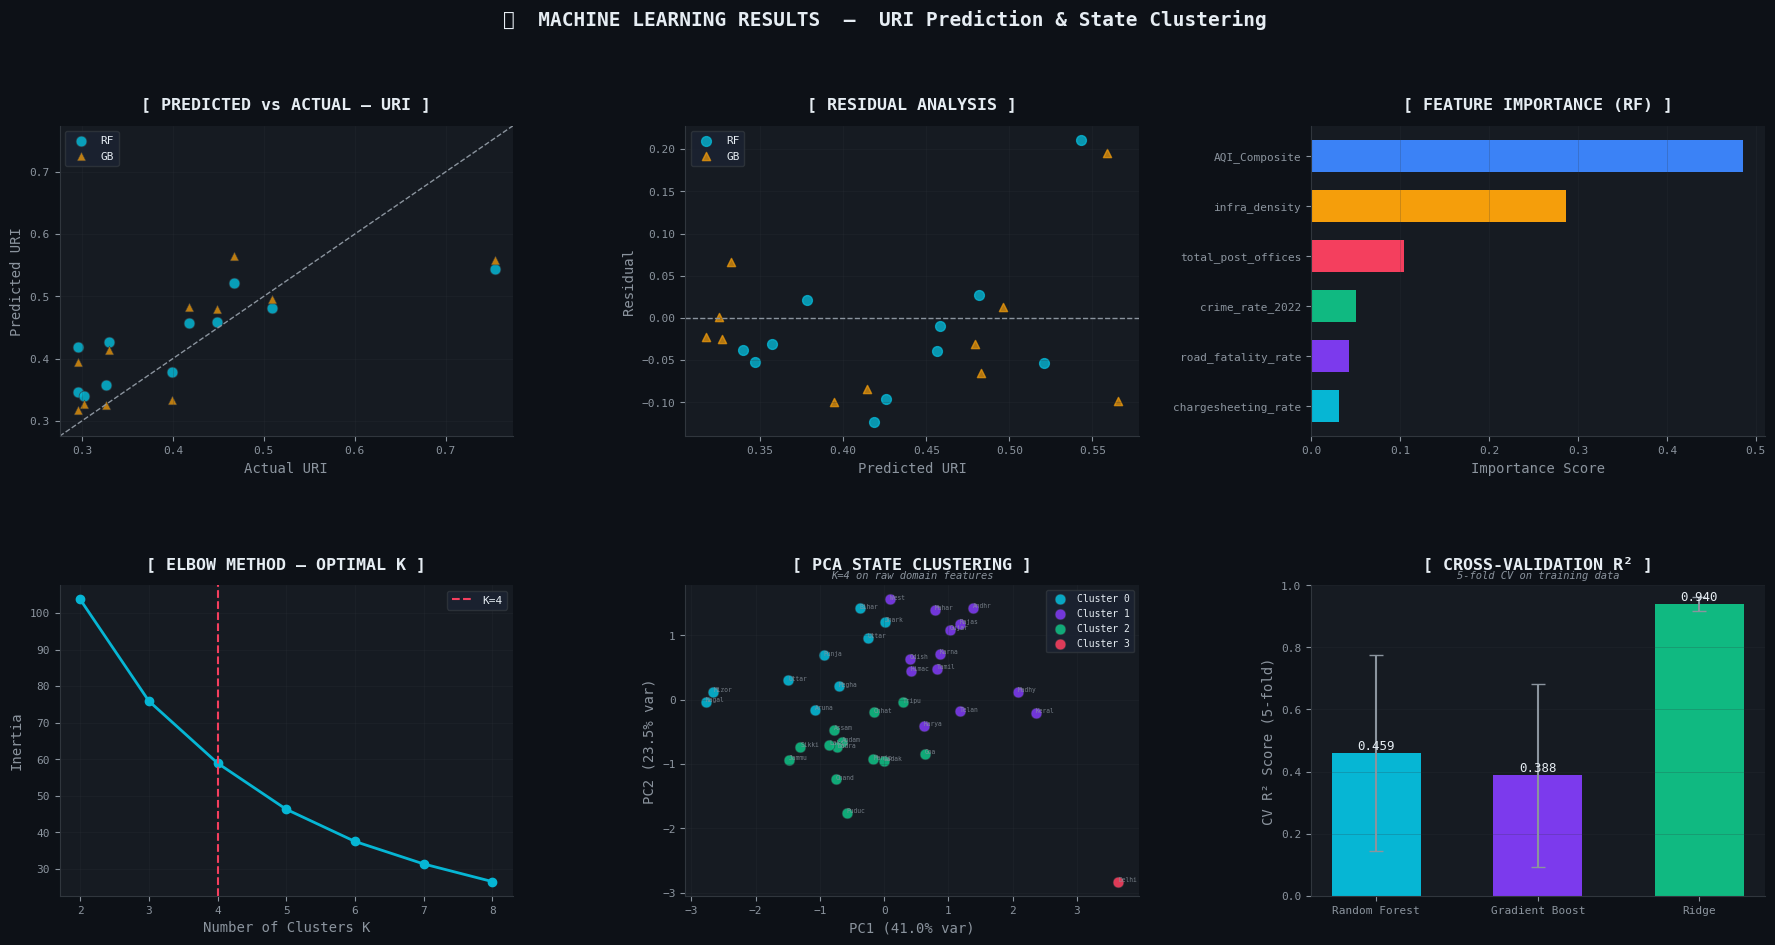

In [42]:
# ── ML Visualisation ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(22, 10), facecolor=DARK_BG)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.48, wspace=0.38)
fig.text(0.5, 0.98, '🤖  MACHINE LEARNING RESULTS  —  URI Prediction & State Clustering',
         ha='center', fontsize=14, fontweight='bold', color=TEXT_PRI, fontfamily='monospace')

# Panel 1: Predicted vs Actual
ax = fig.add_subplot(gs[0, 0])
ax.scatter(y_test, y_pred_rf, color=ACCENT_CYAN, s=60,
           edgecolors=BORDER, linewidths=0.5, alpha=0.85, label='RF')
ax.scatter(y_test, y_pred_gb, color=ACCENT_AMB, s=40,
           edgecolors=BORDER, linewidths=0.5, alpha=0.75, label='GB', marker='^')
lims = [min(y_test.min(), y_pred_rf.min())-0.02,
        max(y_test.max(), y_pred_rf.max())+0.02]
ax.plot(lims, lims, color=TEXT_SEC, lw=1, ls='--')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Actual URI'); ax.set_ylabel('Predicted URI')
ax.legend(); ax.grid(alpha=0.3)
styled_title(ax, '[ PREDICTED vs ACTUAL — URI ]', '')

# Panel 2: Residuals
ax = fig.add_subplot(gs[0, 1])
resid_rf  = y_test - y_pred_rf
resid_gb  = y_test - y_pred_gb
ax.scatter(y_pred_rf, resid_rf, color=ACCENT_CYAN, s=50, alpha=0.8, label='RF')
ax.scatter(y_pred_gb, resid_gb, color=ACCENT_AMB, s=35, alpha=0.7, label='GB', marker='^')
ax.axhline(0, color=TEXT_SEC, lw=1, ls='--')
ax.set_xlabel('Predicted URI'); ax.set_ylabel('Residual')
ax.legend(); ax.grid(alpha=0.3)
styled_title(ax, '[ RESIDUAL ANALYSIS ]', '')

# Panel 3: Feature importance
ax = fig.add_subplot(gs[0, 2])
fi = pd.Series(rf.feature_importances_, index=ML_FEATURES).sort_values(ascending=True)
ax.barh(fi.index, fi.values, color=PALETTE[:len(fi)], edgecolor='none', height=0.65)
ax.set_xlabel('Importance Score')
styled_title(ax, '[ FEATURE IMPORTANCE (RF) ]', '')
ax.grid(axis='x', alpha=0.3)

# Panel 4: Elbow curve
ax = fig.add_subplot(gs[1, 0])
ax.plot(list(K_range), inertias, color=ACCENT_CYAN, lw=2, marker='o', markersize=6)
ax.axvline(OPTIMAL_K, color=ACCENT_ROSE, lw=1.5, ls='--', label=f'K={OPTIMAL_K}')
ax.set_xlabel('Number of Clusters K')
ax.set_ylabel('Inertia')
ax.legend(); ax.grid(alpha=0.3)
styled_title(ax, '[ ELBOW METHOD — OPTIMAL K ]', '')

# Panel 5: PCA cluster scatter
ax = fig.add_subplot(gs[1, 1])
for c in range(OPTIMAL_K):
    mask = fused['Cluster'] == c
    ax.scatter(fused.loc[mask,'PC1'], fused.loc[mask,'PC2'],
               s=60, label=f'Cluster {c}', color=PALETTE[c],
               edgecolors=BORDER, linewidths=0.4, alpha=0.9)
for _, row in fused.iterrows():
    ax.annotate(row['state'][:5], (row['PC1'], row['PC2']),
                fontsize=4.5, color=TEXT_SEC, alpha=0.8)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.legend(fontsize=7); ax.grid(alpha=0.3)
styled_title(ax, '[ PCA STATE CLUSTERING ]', 'K=4 on raw domain features')

# Panel 6: CV score bars
ax = fig.add_subplot(gs[1, 2])
model_names = ['Random Forest','Gradient Boost','Ridge']
cv_means    = [cv_rf.mean(), cv_gb.mean(), cv_rdg.mean()]
cv_stds     = [cv_rf.std(),  cv_gb.std(),  cv_rdg.std()]
bars = ax.bar(model_names, cv_means, color=PALETTE[:3],
              edgecolor='none', width=0.55)
ax.errorbar(model_names, cv_means, yerr=cv_stds,
            fmt='none', color=TEXT_SEC, capsize=5, lw=1.5)
for bar, val in zip(bars, cv_means):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{val:.3f}', ha='center', fontsize=9, color=TEXT_PRI)
ax.set_ylabel('CV R² Score (5-fold)')
ax.set_ylim(0, 1)
ax.set_xticklabels(model_names, fontsize=8)
styled_title(ax, '[ CROSS-VALIDATION R² ]', '5-fold CV on training data')
ax.grid(axis='y', alpha=0.3)

plt.savefig('output_ml_results.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

---
## 🎛️ Phase 8 · Master Dashboard

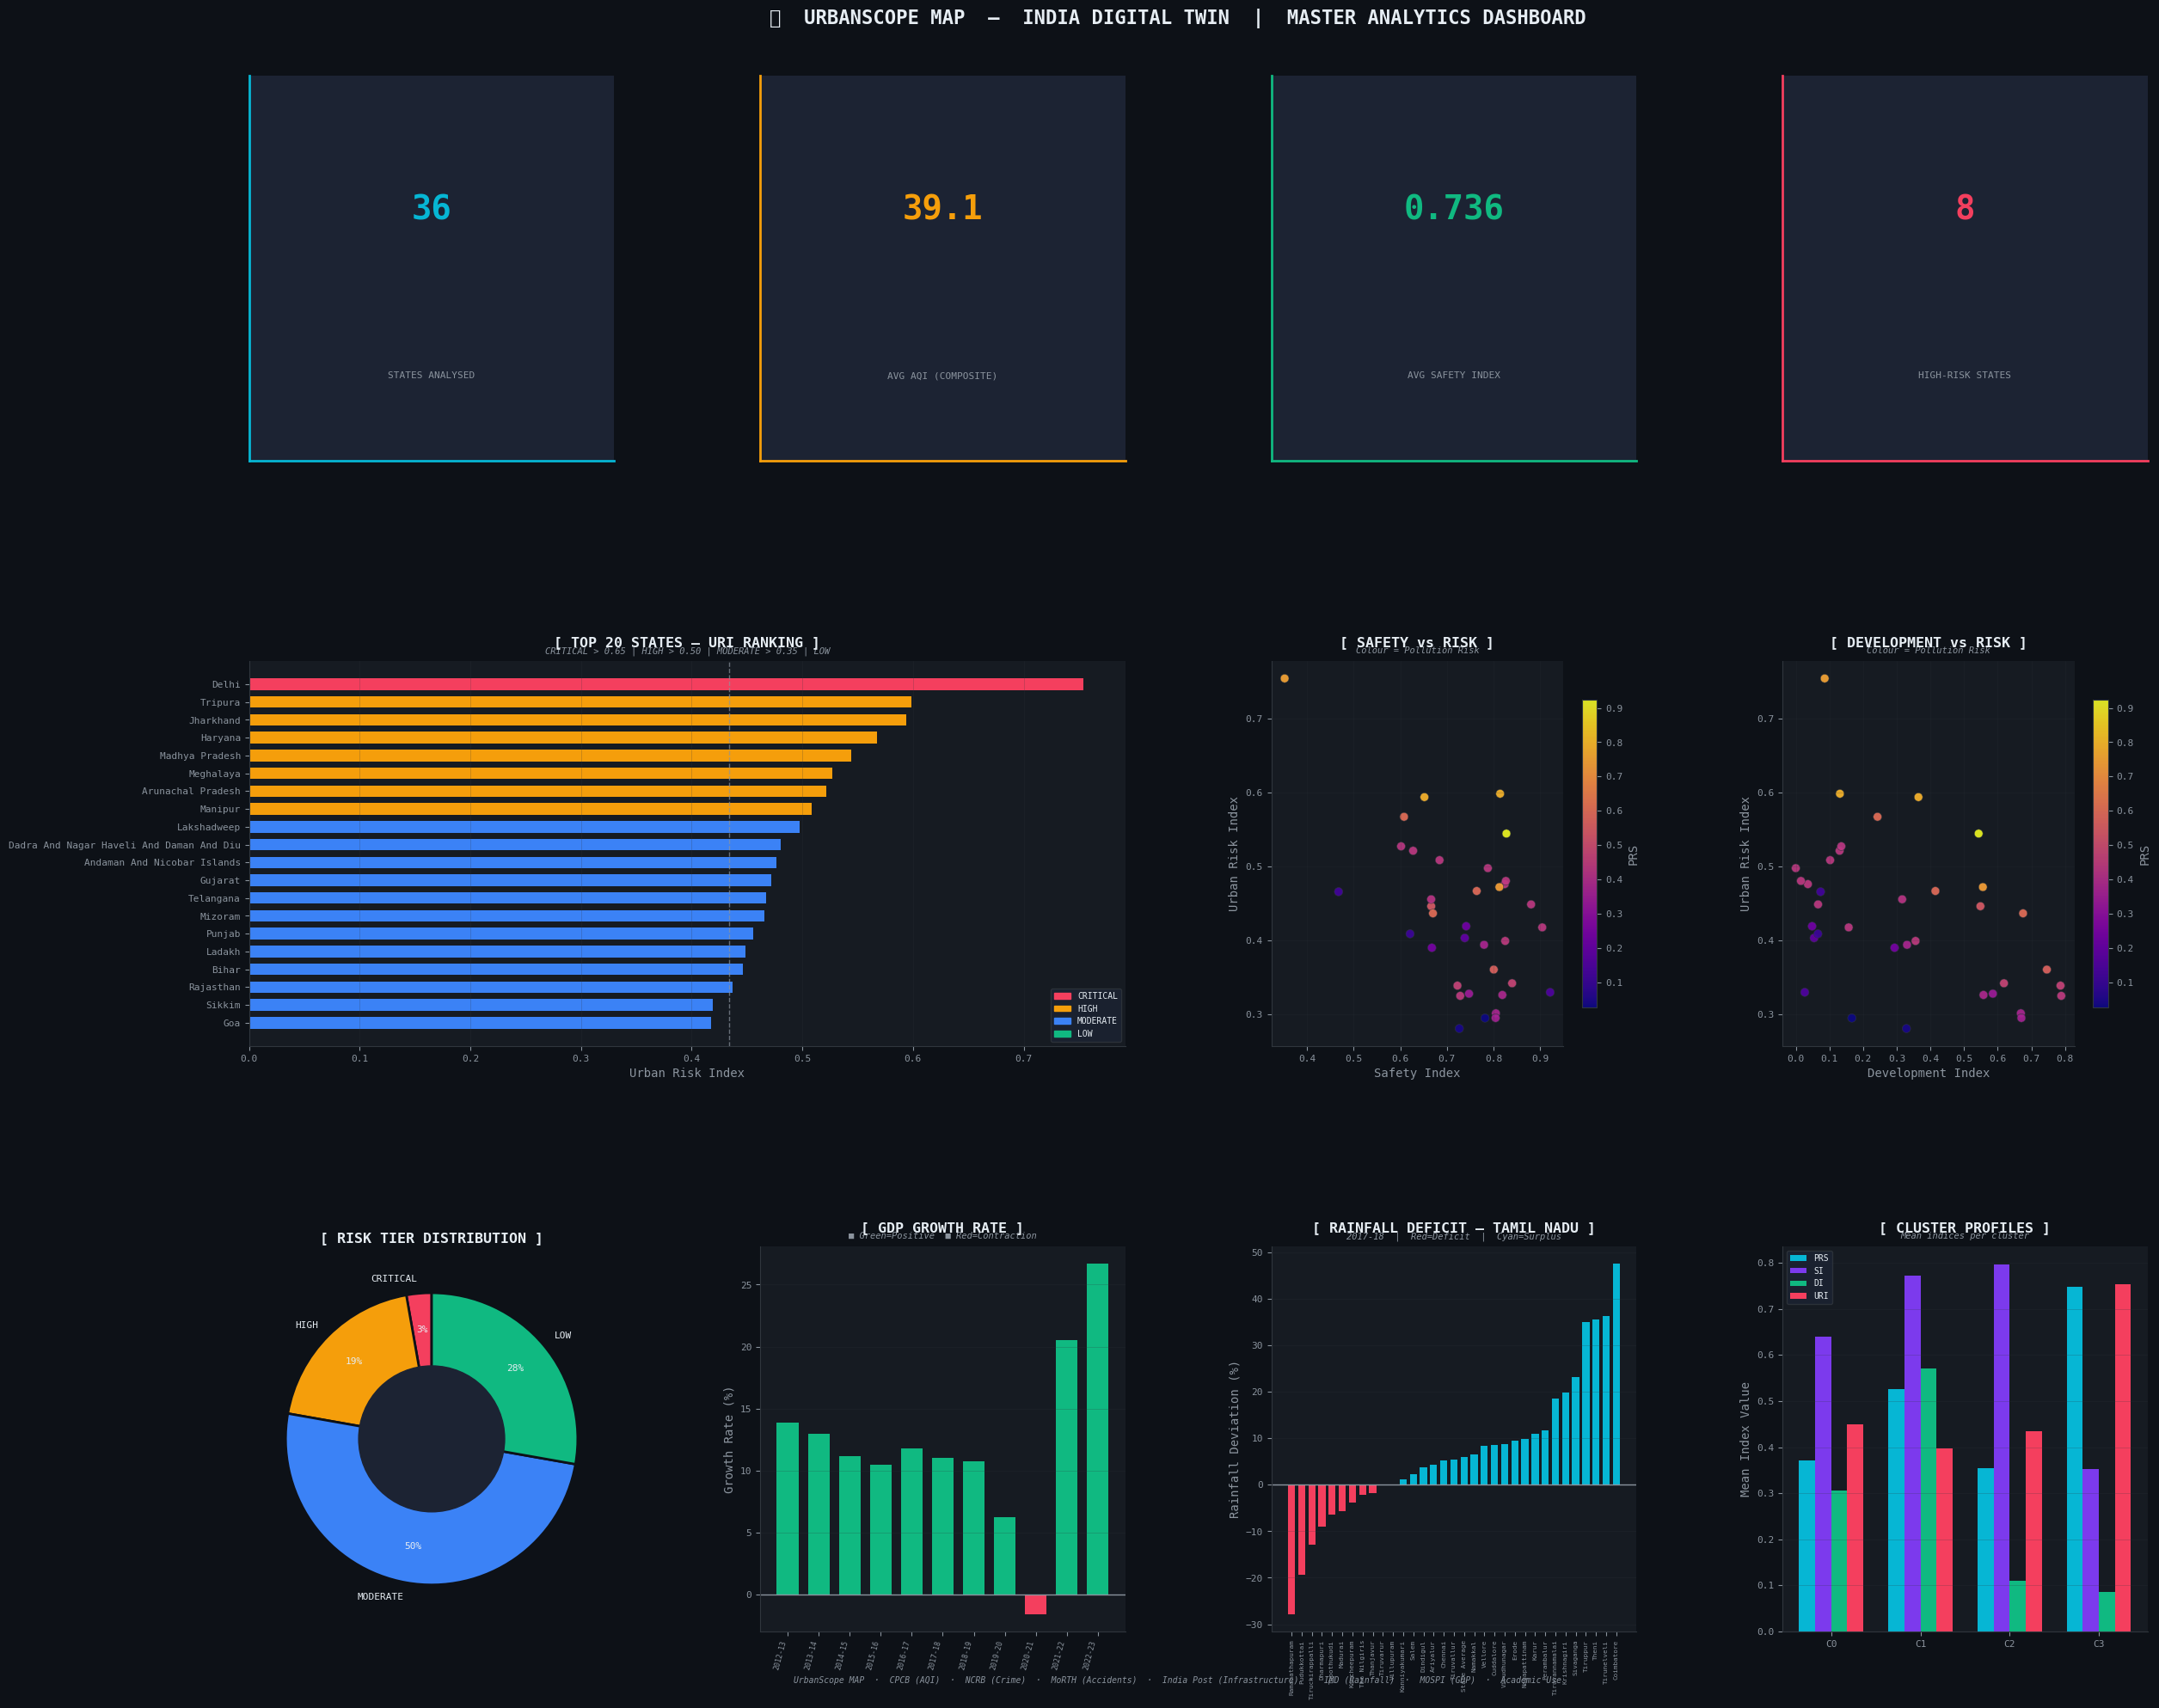


  ✔  Master Dashboard saved → output_master_dashboard.png


In [43]:
# ── MASTER DASHBOARD ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(24, 20), facecolor=DARK_BG)
fig.text(0.5, 0.975, '🌐  URBANSCOPE MAP  —  INDIA DIGITAL TWIN  |  MASTER ANALYTICS DASHBOARD',
         ha='center', fontsize=16, fontweight='bold',
         color=TEXT_PRI, fontfamily='monospace')

gs = gridspec.GridSpec(3, 4, figure=fig,
                       top=0.945, bottom=0.04,
                       hspace=0.52, wspace=0.40,
                       left=0.05, right=0.97)

# ── ROW 0: KPI CARDS ──────────────────────────────────────────────────────────
kpis = [
    ('STATES ANALYSED',      f"{fused['state'].nunique()}",                    ACCENT_CYAN),
    ('AVG AQI (COMPOSITE)', f"{fused['AQI_Composite'].mean():.1f}",            ACCENT_AMB),
    ('AVG SAFETY INDEX',     f"{fused['SI'].mean():.3f}",                      ACCENT_EMER),
    ('HIGH-RISK STATES',     f"{(fused['Risk_Tier'].isin(['CRITICAL','HIGH'])).sum()}", ACCENT_ROSE),
]
for i, (label, value, color) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, i])
    ax.set_facecolor(CARD_BG)
    for spine in ax.spines.values(): spine.set_edgecolor(color); spine.set_linewidth(2)
    ax.text(0.5, 0.65, value, ha='center', va='center',
            fontsize=28, fontweight='bold', color=color, transform=ax.transAxes)
    ax.text(0.5, 0.22, label, ha='center', va='center',
            fontsize=8, color=TEXT_SEC, fontfamily='monospace', transform=ax.transAxes)
    ax.set_xticks([]); ax.set_yticks([])

# ── ROW 1: URI RANKING ────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, :2])
uri_sorted = fused.sort_values('URI', ascending=True).tail(20)
tier_c = {'CRITICAL':ACCENT_ROSE,'HIGH':ACCENT_AMB,
          'MODERATE':ACCENT_BLUE,'LOW':ACCENT_EMER}
bar_colors = [tier_c[t] for t in uri_sorted['Risk_Tier']]
ax.barh(uri_sorted['state'], uri_sorted['URI'],
        color=bar_colors, edgecolor='none', height=0.65)
ax.axvline(fused['URI'].mean(), color=TEXT_SEC, lw=1, ls='--', alpha=0.7)
for patch in [mpatches.Patch(color=c, label=l)
              for l,c in tier_c.items()]:
    pass
ax.legend(handles=[mpatches.Patch(color=c,label=l)
                   for l,c in tier_c.items()],
          loc='lower right', fontsize=7)
ax.set_xlabel('Urban Risk Index')
styled_title(ax, '[ TOP 20 STATES — URI RANKING ]',
             'CRITICAL > 0.65 | HIGH > 0.50 | MODERATE > 0.35 | LOW')
ax.grid(axis='x', alpha=0.3)

# ── ROW 1: SAFETY vs URI scatter ──────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 2])
sc = ax.scatter(fused['SI'], fused['URI'],
                c=fused['PRS'], cmap='plasma', s=50,
                edgecolors=BORDER, linewidths=0.4, alpha=0.9)
plt.colorbar(sc, ax=ax, label='PRS', shrink=0.8)
ax.set_xlabel('Safety Index')
ax.set_ylabel('Urban Risk Index')
styled_title(ax, '[ SAFETY vs RISK ]', 'Colour = Pollution Risk')
ax.grid(alpha=0.25)

# ── ROW 1: Development vs URI ─────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 3])
sc = ax.scatter(fused['DI'], fused['URI'],
                c=fused['PRS'], cmap='plasma', s=50,
                edgecolors=BORDER, linewidths=0.4, alpha=0.9)
plt.colorbar(sc, ax=ax, label='PRS', shrink=0.8)
ax.set_xlabel('Development Index')
ax.set_ylabel('Urban Risk Index')
styled_title(ax, '[ DEVELOPMENT vs RISK ]', 'Colour = Pollution Risk')
ax.grid(alpha=0.25)

# ── ROW 2: GDP GROWTH ─────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[2, 1])
if not gdp_total.empty:
    gdp_t = gdp_total.sort_values('year').dropna(subset=['growth_rate_pct'])
    colors_g = [ACCENT_EMER if v>=0 else ACCENT_ROSE for v in gdp_t['growth_rate_pct']]
    ax.bar(range(len(gdp_t)), gdp_t['growth_rate_pct'],
           color=colors_g, edgecolor='none', width=0.7)
    ax.axhline(0, color=TEXT_SEC, lw=1)
    ax.set_xticks(range(len(gdp_t)))
    ax.set_xticklabels(gdp_t['year'], rotation=75, ha='right', fontsize=6)
    ax.set_ylabel('Growth Rate (%)')
styled_title(ax, '[ GDP GROWTH RATE ]', '■ Green=Positive  ■ Red=Contraction')
ax.grid(axis='y', alpha=0.3)

# ── ROW 2: RAINFALL ───────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[2, 2])
rain_s2 = rain.sort_values('deficit_pct')
c_rain  = [ACCENT_ROSE if v<0 else ACCENT_CYAN for v in rain_s2['deficit_pct']]
ax.bar(range(len(rain_s2)), rain_s2['deficit_pct'],
       color=c_rain, edgecolor='none', width=0.7)
ax.axhline(0, color=TEXT_SEC, lw=1)
ax.set_xticks(range(len(rain_s2)))
ax.set_xticklabels(rain_s2['district'], rotation=90, fontsize=5.5)
ax.set_ylabel('Rainfall Deviation (%)')
styled_title(ax, '[ RAINFALL DEFICIT — TAMIL NADU ]',
             '2017-18  |  Red=Deficit  |  Cyan=Surplus')
ax.grid(axis='y', alpha=0.3)

# ── ROW 2: CLUSTER PROFILES ───────────────────────────────────────────────────
ax = fig.add_subplot(gs[2, 3])
cluster_means = fused.groupby('Cluster')[['PRS','SI','DI','URI']].mean()
x_pos = np.arange(OPTIMAL_K)
w = 0.18
for i, feat in enumerate(['PRS','SI','DI','URI']):
    ax.bar(x_pos+i*w, cluster_means[feat], width=w,
           color=PALETTE[i], label=feat, edgecolor='none')
ax.set_xticks(x_pos+1.5*w)
ax.set_xticklabels([f'C{c}' for c in range(OPTIMAL_K)])
ax.set_ylabel('Mean Index Value')
ax.legend(fontsize=7)
styled_title(ax, '[ CLUSTER PROFILES ]', 'Mean indices per cluster')
ax.grid(axis='y', alpha=0.3)

# ── ROW 2: RISK TIER DONUT ────────────────────────────────────────────────────
ax = fig.add_subplot(gs[2, 0])
tier_counts = fused['Risk_Tier'].value_counts()
tier_order  = [t for t in ['CRITICAL','HIGH','MODERATE','LOW'] if t in tier_counts.index]
tier_vals   = [tier_counts[t] for t in tier_order]
tier_cols   = [tier_c[t] for t in tier_order]
wedges, texts, autotexts = ax.pie(
    tier_vals, labels=tier_order, colors=tier_cols,
    autopct='%1.0f%%', startangle=90,
    pctdistance=0.75,
    wedgeprops={'edgecolor':DARK_BG,'linewidth':2},
    textprops={'color':TEXT_PRI,'fontsize':8})
ax.add_artist(plt.Circle((0,0), 0.50, color=CARD_BG))
styled_title(ax, '[ RISK TIER DISTRIBUTION ]', '')

fig.text(0.5, 0.01,
         'UrbanScope MAP  ·  CPCB (AQI)  ·  NCRB (Crime)  ·  MoRTH (Accidents)'
         '  ·  India Post (Infrastructure)  ·  IMD (Rainfall)  ·  MOSPI (GDP)  ·  Academic Use',
         ha='center', fontsize=7, color=TEXT_SEC, style='italic')

plt.savefig('output_master_dashboard.png', dpi=160, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print('\n  ✔  Master Dashboard saved → output_master_dashboard.png')

---
## 💾 Export — Fused Dataset & Summary

In [44]:
export_cols = [c for c in [
    'state','AQI_Composite','PM2.5','PM10','NO2','SO2','CO',
    'crime_rate_2022','crime_yoy_pct','chargesheeting_rate',
    'road_deaths','road_fatality_rate','total_post_offices',
    'total_districts','infra_density','PRS','SI','DI','URI','Risk_Tier','Cluster'
] if c in fused.columns]

fused_export = fused[export_cols].sort_values('URI', ascending=False)
fused_export.to_csv('urbanscope_fused_dataset.csv', index=False)

section_header('UrbanScope MAP — Pipeline Complete', '🎉')
print('  Outputs generated:')
for f in ['urbanscope_fused_dataset.csv','output_aqi_eda.png',
          'output_crime_eda.png','output_accidents_eda.png',
          'output_gdp_eda.png','output_rainfall_eda.png',
          'output_correlation.png','output_ml_results.png',
          'output_master_dashboard.png']:
    print(f'    ├── {f}')
print()
print('  Fused Dataset Preview (Top 10 by URI):')
print(fused_export[['state','PRS','SI','DI','URI','Risk_Tier']].head(10).to_string(index=False))
print()
print('  UrbanScope MAP — India Digital Twin Analysis Complete ✓')


────────────────────────────────────────────────────────────────────────
  🎉  UrbanScope MAP — Pipeline Complete
────────────────────────────────────────────────────────────────────────

  Outputs generated:
    ├── urbanscope_fused_dataset.csv
    ├── output_aqi_eda.png
    ├── output_crime_eda.png
    ├── output_accidents_eda.png
    ├── output_gdp_eda.png
    ├── output_rainfall_eda.png
    ├── output_correlation.png
    ├── output_ml_results.png
    ├── output_master_dashboard.png

  Fused Dataset Preview (Top 10 by URI):
                                   state    PRS     SI     DI    URI Risk_Tier
                                   Delhi 0.7472 0.3520 0.0859 0.7542  CRITICAL
                                 Tripura 0.7901 0.8140 0.1311 0.5984      HIGH
                               Jharkhand 0.7824 0.6517 0.3644 0.5938      HIGH
                                 Haryana 0.6017 0.6080 0.2428 0.5672      HIGH
                          Madhya Pradesh 0.9248 0.8275 0.5432 0.5445    

---

<div style="background:linear-gradient(135deg,#0f0c29,#302b63);padding:30px 40px;border-radius:16px;border:1px solid #7c3aed;margin-top:20px;">
  <h2 style="color:#a78bfa;font-family:monospace;margin:0 0 16px 0;">📘 Methodology Notes</h2>
  <table style="width:100%;border-collapse:collapse;color:#94a3b8;font-size:0.9em;">
    <tr><th style="text-align:left;padding:8px 12px;color:#e6edf3;border-bottom:1px solid #30363d;">Module</th><th style="text-align:left;padding:8px 12px;color:#e6edf3;border-bottom:1px solid #30363d;">Technique</th><th style="text-align:left;padding:8px 12px;color:#e6edf3;border-bottom:1px solid #30363d;">Note</th></tr>
    <tr><td style="padding:7px 12px;">AQI Aggregation</td><td>Weighted composite (IS-based weights)</td><td>Custom index — not official AQI</td></tr>
    <tr><td style="padding:7px 12px;">Data Fusion</td><td>Outer merge on normalised state key</td><td>Canonical state-name map resolves mismatches</td></tr>
    <tr><td style="padding:7px 12px;">Feature Engineering</td><td>MinMax-normalised weighted sum</td><td>PRS / SI / DI / URI</td></tr>
    <tr><td style="padding:7px 12px;">ML Prediction</td><td>RF + GB + Ridge (5-fold CV)</td><td>Raw features only — no leakage</td></tr>
    <tr><td style="padding:7px 12px;">Clustering</td><td>K-Means (K=4) + PCA 2D</td><td>Raw domain features; URI excluded to prevent circularity</td></tr>
    <tr><td style="padding:7px 12px;">Imputation</td><td>Column-wise median fill (assignment form)</td><td>pandas 2.x safe — no inplace on slices</td></tr>
    <tr><td style="padding:7px 12px;">Rainfall</td><td>Tamil Nadu only (2017-18)</td><td>Kept separate — not imputed nationally</td></tr>
  </table>
  <p style="color:#64748b;font-size:0.8em;margin:16px 0 0 0;">UrbanScope MAP · Academic Project · India Digital Twin · Multi-Domain Analytics Platform</p>
</div>